# Interpretable Graph Neural Networks for Topological Insulators
## Charles Model — Full Pipeline: RF, XGBoost, CGCNN, MEGNet, Attention GNN

**Project Goal:** Classify materials as Topological Insulators (TI) vs Trivial using tabular baseline models
(Random Forest, XGBoost) and Graph Neural Networks (CGCNN, MEGNet), then extract interpretable
physical rules using SHAP, attention heatmaps, GNNExplainer, and PySR symbolic regression.

**References:**
- Xie & Grossman (2018) — Crystal Graph Convolutional Neural Networks (CGCNN)
- Chen et al. (2019) — MatErials Graph Network (MEGNet)
- Velicković et al. (2018) — Graph Attention Networks (GAT)
- Lundberg & Lee (2017) — SHAP (SHapley Additive exPlanations)
- PyTorch Geometric Docs — CGConv, GATConv, GNNExplainer
- Scikit-learn Docs — train_test_split (stratified)
- Pymatgen Docs — CifParser

## Step 1 — Mount Google Drive

We mount Google Drive so that `Dataset.csv` and the `cif_files/` folder inside your `Project/` folder
are accessible. After mounting, we set the working directory path.

In [ ]:
# Mount Google Drive to access your Project folder
from google.colab import drive
drive.mount('/content/drive')

import os

# Set the base path to your Project folder on Google Drive.
BASE_DIR = '/content/drive/MyDrive/Project'

# Set convenient path shortcuts
DATA_PATH = os.path.join(BASE_DIR, 'Dataset.csv')   # path to CSV file
CIF_BASE  = BASE_DIR                                  # CIF paths in CSV are relative e.g. cif_files/mp-331.cif

# Verify the paths exist
print("Base directory exists:", os.path.isdir(BASE_DIR))
print("Dataset.csv exists   :", os.path.isfile(DATA_PATH))
print("cif_files/ exists    :", os.path.isdir(os.path.join(BASE_DIR, 'cif_files')))

Mounted at /content/drive
Base directory exists: True
Dataset.csv exists   : True
cif_files/ exists    : True


## Step 2 — Install Required Libraries

We install PyTorch Geometric (PyG) for graph neural networks, pymatgen for parsing CIF crystal
structure files, SHAP for interpretability, PySR for symbolic regression, and supporting packages.
Run this cell **once** per Colab session.

**Key packages:**
- `torch-geometric` — CGConv, GATConv, GNNExplainer, DataLoader (Fey & Lenssen, 2019)
- `torch-cluster` — `radius_graph` for building atom neighbor graphs
- `pymatgen` — CIF parsing, crystal structure objects (Ong et al., 2013)
- `shap` — Shapley-value feature importance (Lundberg & Lee, 2017)
- `pysr` — Symbolic regression to discover human-readable formulas

In [ ]:
# ---------------------------------------------------------------
# Install PyTorch Geometric and dependencies.
# We install torch-cluster for radius_graph (neighbor search).
# The -f flag points pip to the pre-built PyG wheel repository.
# ---------------------------------------------------------------
import subprocess, sys

# Install torch-geometric (pure Python, no compiled extension needed for CGConv)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"], check=True)

# Install torch-cluster (needed for radius_graph)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-cluster"], check=True)

# Install pymatgen for CIF parsing
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymatgen"], check=True)

# Install SHAP (Shapley Additive exPlanations)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=True)

# Install PySR (symbolic regression, uses Julia under the hood)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pysr"], check=True)

# Install XGBoost (gradient boosted trees)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost"], check=True)

print("All libraries installed successfully!")

All libraries installed successfully!


## Step 3 — Import All Libraries

We import every library used throughout the notebook. Keeping all imports in one cell makes
dependencies transparent and easy to debug.

In [ ]:
# ---------------------------------------------------------------
# Standard Python libraries
# ---------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')           # suppress non-critical warnings

# ---------------------------------------------------------------
# Machine learning — scikit-learn
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix)
from sklearn.preprocessing import label_binarize

# ---------------------------------------------------------------
# XGBoost — gradient boosted trees
# ---------------------------------------------------------------
import xgboost as xgb
from xgboost import XGBClassifier

# ---------------------------------------------------------------
# SHAP — feature interpretability
# ---------------------------------------------------------------
import shap

# ---------------------------------------------------------------
# PyTorch — deep learning framework
# ---------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)                       # seed for reproducibility

# ---------------------------------------------------------------
# PyTorch Geometric — graph neural networks
# Refs: Fey & Lenssen (2019), PyG docs
# ---------------------------------------------------------------
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (CGConv,          # Crystal Graph Conv (Xie & Grossman 2018)
                                 GATConv,         # Graph Attention (Velicković 2018)
                                 global_mean_pool,# pooling node → graph
                                 Set2Set)         # advanced pooling for MEGNet

# ---------------------------------------------------------------
# torch_cluster — radius_graph for spatial neighbor search
# ---------------------------------------------------------------
from torch_cluster import radius_graph

# ---------------------------------------------------------------
# Pymatgen — crystal structure parsing from CIF files
# Ref: Ong et al. (2013)
# ---------------------------------------------------------------
from pymatgen.io.cif import CifParser

# ---------------------------------------------------------------
# PySR — symbolic regression
# ---------------------------------------------------------------
from pysr import PySRRegressor

# Set device: use GPU (CUDA) if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("All imports successful!")

Using device: cpu
All imports successful!


## Step 4 — Load Dataset

We load `Dataset.csv` into a pandas DataFrame. The dataset contains 7000 materials with columns:
`mp_material_id`, `mp_formula`, `spacegroup`, `spacegroup_number`, `number of atoms`, `Band Gap`,
`a`, `b`, `c`, `alpha`, `beta`, `gamma`, `Z`, `electronegativity`, `Topological Label`, `label`, `cif`.

We keep the `cif` column as a **string path** (not encoded) so we can use it to locate CIF files later.

In [ ]:
# Load the dataset from CSV
df = pd.read_csv(DATA_PATH)

# Print basic info
print("Dataset shape:", df.shape)           # rows x columns
print("\nColumn names:")
print(df.columns.tolist())

# Show the first few rows
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: (7000, 17)

Column names:
['mp_material_id', 'mp_formula', 'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'Topological Label', 'label', 'cif']

First 3 rows:


,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-331,ScAl,Pm3m,221,2.0,0.0000,3.370349,3.370349,3.370349,90.000000,90.00000,90.000000,1.0,1.485,TI,1,cif_files/mp-331.cif
1,mp-698479,RbTeHOF4,Cc,9,32.0,4.8825,8.430517,8.430517,14.075609,85.886490,85.88649,34.382176,6.4,3.060,Trivial,0,cif_files/mp-698479.cif
2,mp-549237,Sr2Fe2S2OF2,I4/mmm,139,18.0,1.4677,4.095118,4.096245,18.221803,90.002343,90.00368,89.993481,3.6,2.458,Trivial,0,cif_files/mp-549237.cif


## Step 5 — Encode Categorical Features and Select Model Features

**Encoding strategy** (matches Project.ipynb):
- We encode the `spacegroup` column (text symmetry symbol e.g. "Pm3m") to integer codes
  using `pandas.Categorical.codes` — same approach used in the existing project code.
- We also encode `mp_formula` if it is object type.
- We **do NOT** encode the `cif` column — it holds file paths needed for graph construction.
- The `Topological Label` column ("TI"/"Trivial") is encoded: TI → 1, Trivial → 0.

**Feature set for tabular models (12 features):**
`spacegroup`, `spacegroup_number`, `number of atoms`, `Band Gap`,
`a`, `b`, `c`, `alpha`, `beta`, `gamma`, `Z`, `electronegativity`

These same 11 numeric descriptors (spacegroup after encoding) also become the **global feature vector**
in our GNN models.

In [ ]:
# ---------------------------------------------------------------
# Encode categorical string columns, EXCEPT 'cif' which is a file path
# This matches the encoding used in Project.ipynb
# ---------------------------------------------------------------
cols_to_encode = [col for col in df.select_dtypes(include='object').columns
                  if col not in ('cif',)]       # exclude cif from encoding

print("Columns being encoded:", cols_to_encode)

for col in cols_to_encode:
    # astype('category') assigns integer codes to each unique string
    df[col] = df[col].astype('category').cat.codes

# Confirm encoding: Topological Label should now be 0 or 1
# But we use the pre-existing 'label' column (already 0/1) as our target
print("\nLabel value counts (0=Trivial, 1=TI):")
print(df['label'].value_counts())

# ---------------------------------------------------------------
# Define the 12 tabular features used for RF and XGBoost
# These 12 columns are also the global feature vector 'u' for GNNs
# ---------------------------------------------------------------
FEATURES = [
    'spacegroup',          # encoded symmetry symbol (categorical → int)
    'spacegroup_number',   # international space group number (1–230)
    'number of atoms',     # number of atoms per unit cell
    'Band Gap',            # electronic band gap in eV
    'a', 'b', 'c',         # lattice constants in Angstroms
    'alpha', 'beta', 'gamma',  # lattice angles in degrees
    'Z',                   # average atomic number
    'electronegativity'    # average Pauling electronegativity
]

TARGET = 'label'           # binary target: 1=TI, 0=Trivial

# Keep only feature+target rows with no missing values
df_model = df[FEATURES + [TARGET, 'cif']].dropna()

print(f"\nAfter dropping NaN rows: {df_model.shape[0]} samples remain")
print(f"Feature count: {len(FEATURES)}")

# Separate feature matrix X and target vector y (for tabular models)
X = df_model[FEATURES].copy()   # shape [N, 12]
y = df_model[TARGET].copy()     # shape [N,]

print("\nFeature matrix X shape:", X.shape)
print("Target vector y shape  :", y.shape)

Columns being encoded: ['mp_material_id', 'mp_formula', 'spacegroup', 'Topological Label']

Label value counts (0=Trivial, 1=TI):
label
0    3536
1    3464
Name: count, dtype: int64

After dropping NaN rows: 7000 samples remain
Feature count: 12

Feature matrix X shape: (7000, 12)
Target vector y shape  : (7000,)


## Step 6 — Check Class Balance

Before splitting, we visualise the class distribution to confirm the dataset is reasonably balanced
between Topological (TI=1) and Trivial (0) insulators. This also informs our choice of stratified
splitting and the `class_weight='balanced'` option in Random Forest.

Class counts:
  Trivial (0): 3536  (50.5%)
  Topological (1): 3464  (49.5%)


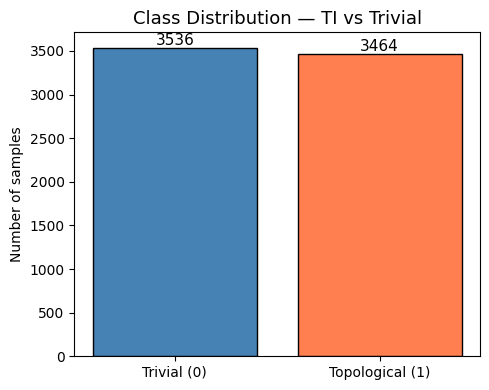

In [ ]:
# Count samples per class
class_counts = y.value_counts().sort_index()
class_pct    = y.value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(f"  Trivial (0): {class_counts[0]}  ({class_pct[0]:.1f}%)")
print(f"  Topological (1): {class_counts[1]}  ({class_pct[1]:.1f}%)")

# ---------------------------------------------------------------
# Bar plot of class distribution
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Trivial (0)', 'Topological (1)'],
       [class_counts[0], class_counts[1]],
       color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Class Distribution — TI vs Trivial', fontsize=13)
ax.set_ylabel('Number of samples')
for i, v in enumerate([class_counts[0], class_counts[1]]):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Step 7 — Stratified Train / Validation / Test Split (70 / 15 / 15)

We split the data into:
- **Training set** — 70% of data — used to fit models
- **Validation set** — 15% — used to tune hyperparameters and monitor training
- **Test set** — 15% — held out for final unbiased evaluation

We use `stratify=y` in both splits so that the fraction of TI vs Trivial is preserved in every subset.
This is important because even slight class imbalance can bias evaluation metrics.

Reference: scikit-learn `train_test_split` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [ ]:
# ---------------------------------------------------------------
# Step 1: Split into 70% train and 30% temp
# stratify=y ensures class ratios are preserved
# ---------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,          # 30% goes into temp (will be split again)
    stratify=y,              # preserve TI/Trivial ratio
    random_state=42          # reproducibility seed
)

# ---------------------------------------------------------------
# Step 2: Split the 30% temp into 15% val and 15% test
# 0.50 of 30% = 15% of total
# ---------------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # half of temp → test, half → validation
    stratify=y_temp,
    random_state=42
)

# ---------------------------------------------------------------
# Report split sizes and class fractions
# ---------------------------------------------------------------
print(f"Train      : {X_train.shape[0]} samples  "
      f"| TI fraction: {y_train.mean():.3f}")
print(f"Validation : {X_val.shape[0]} samples  "
      f"| TI fraction: {y_val.mean():.3f}")
print(f"Test       : {X_test.shape[0]} samples  "
      f"| TI fraction: {y_test.mean():.3f}")

# ---------------------------------------------------------------
# Also keep aligned DataFrame rows for GNN graph construction later
# ---------------------------------------------------------------
# We need the 'cif' column to build graphs, so keep a full-row copy
df_train = df_model.loc[X_train.index].reset_index(drop=True)
df_val   = df_model.loc[X_val.index].reset_index(drop=True)
df_test  = df_model.loc[X_test.index].reset_index(drop=True)

print(f"\ndf_train rows: {len(df_train)} | df_val rows: {len(df_val)} | df_test rows: {len(df_test)}")

Train      : 4900 samples  | TI fraction: 0.495
Validation : 1050 samples  | TI fraction: 0.495
Test       : 1050 samples  | TI fraction: 0.494

df_train rows: 4900 | df_val rows: 1050 | df_test rows: 1050


## Step 8 — Random Forest Model

Random Forest is an ensemble of decision trees that achieves high accuracy and provides natural feature
importance via mean decrease in impurity (MDI). We set `class_weight='balanced'` to handle any residual
class imbalance and use 500 trees for stability.

We evaluate on **validation** and **test** sets reporting Accuracy, F1-score, and ROC-AUC.

In [ ]:
# ---------------------------------------------------------------
# Initialise Random Forest Classifier
# n_estimators=500 → 500 decision trees in the ensemble
# class_weight='balanced' → automatically adjusts for class imbalance
# random_state=42 → reproducibility
# ---------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,           # trees grow fully (no depth limit)
    min_samples_split=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                 # use all available CPU cores
)

# Fit (train) the Random Forest on the training data
rf.fit(X_train, y_train)
print("Random Forest training complete.")

# ---------------------------------------------------------------
# Evaluate on Validation Set
# ---------------------------------------------------------------
y_val_pred_rf  = rf.predict(X_val)
y_val_prob_rf  = rf.predict_proba(X_val)[:, 1]   # probability for class 1

val_acc_rf  = accuracy_score(y_val, y_val_pred_rf)
val_f1_rf   = f1_score(y_val, y_val_pred_rf)
val_auc_rf  = roc_auc_score(y_val, y_val_prob_rf)

print(f"\n--- Random Forest Validation ---")
print(f"  Accuracy : {val_acc_rf:.4f}")
print(f"  F1-score : {val_f1_rf:.4f}")
print(f"  ROC-AUC  : {val_auc_rf:.4f}")

# ---------------------------------------------------------------
# Evaluate on Test Set (final unbiased result)
# ---------------------------------------------------------------
y_test_pred_rf = rf.predict(X_test)
y_test_prob_rf = rf.predict_proba(X_test)[:, 1]

test_acc_rf  = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf   = f1_score(y_test, y_test_pred_rf)
test_auc_rf  = roc_auc_score(y_test, y_test_prob_rf)

print(f"\n--- Random Forest Test ---")
print(f"  Accuracy : {test_acc_rf:.4f}")
print(f"  F1-score : {test_f1_rf:.4f}")
print(f"  ROC-AUC  : {test_auc_rf:.4f}")
print("\nDetailed Classification Report (Test):")
print(classification_report(y_test, y_test_pred_rf,
                            target_names=['Trivial', 'Topological']))

Random Forest training complete.

--- Random Forest Validation ---
  Accuracy : 0.8838
  F1-score : 0.8802
  ROC-AUC  : 0.9436

--- Random Forest Test ---
  Accuracy : 0.8571
  F1-score : 0.8524
  ROC-AUC  : 0.9338

Detailed Classification Report (Test):
              precision    recall  f1-score   support

     Trivial       0.84      0.88      0.86       531
 Topological       0.87      0.83      0.85       519

    accuracy                           0.86      1050
   macro avg       0.86      0.86      0.86      1050
weighted avg       0.86      0.86      0.86      1050



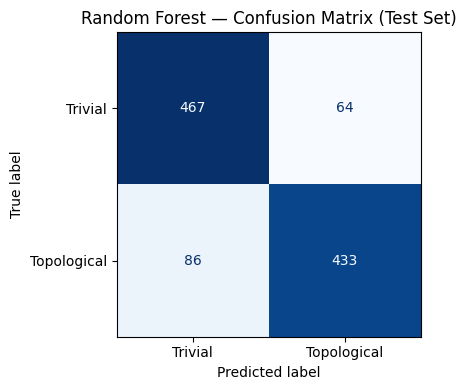

In [ ]:
# ---------------------------------------------------------------
# Confusion matrix for Random Forest (Test set)
# ---------------------------------------------------------------
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Trivial', 'Topological'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## Step 9 — SHAP Interpretation for Random Forest

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine
learning model. For tree-based models, `shap.TreeExplainer` computes exact Shapley values efficiently.

We produce five standard SHAP plots:
1. **Summary / Beeswarm** — each dot is one sample; colour = feature value; x-position = SHAP impact
2. **Bar plot** — mean |SHAP value| per feature (global importance)
3. **Waterfall plot** — how each feature pushes one individual prediction
4. **Force plot** — compact version of waterfall for one sample
5. **Dependence plot** — how one feature's SHAP value varies with its actual value

Reference: Lundberg & Lee (2017) — https://shap.readthedocs.io

SHAP values shape: (4900, 12, 2)

--- Plot 1: SHAP Beeswarm (Summary Plot) ---


<Figure size 900x600 with 0 Axes>

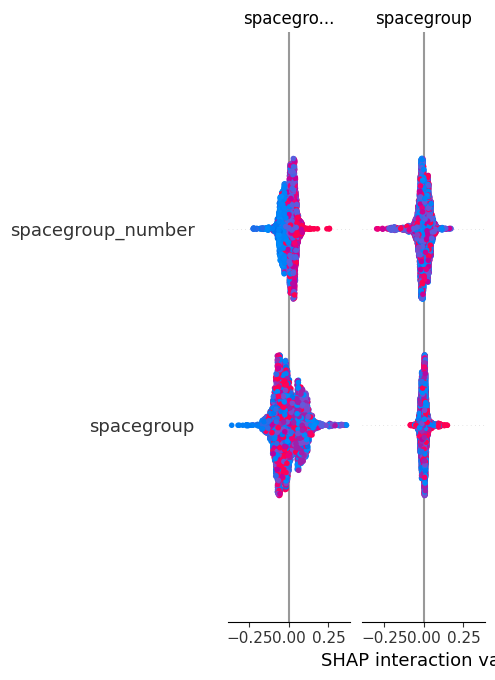


--- Plot 2: SHAP Bar Plot ---


<Figure size 900x600 with 0 Axes>

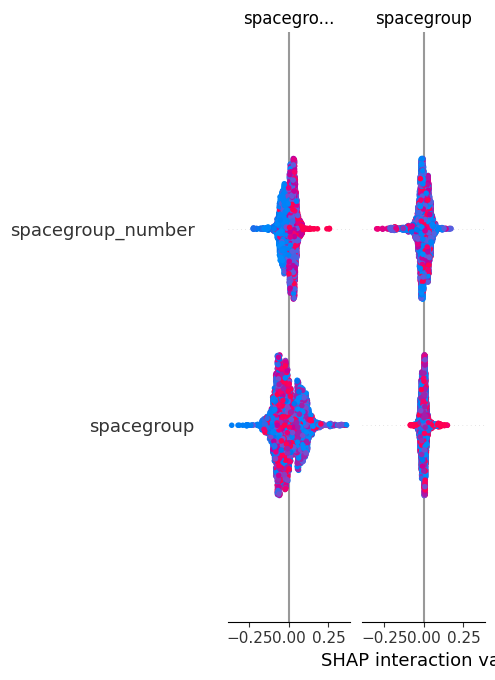

In [ ]:
# ---------------------------------------------------------------
# Create SHAP TreeExplainer for Random Forest
# TreeExplainer is exact and fast for tree-based models
# ---------------------------------------------------------------
rf_explainer  = shap.TreeExplainer(rf)

# Compute SHAP values on the TRAINING set
# shap_values_rf has shape [n_train, n_features] for binary classification
# We use index [1] to get SHAP values for the POSITIVE class (Topological=1)
shap_vals_rf  = rf_explainer.shap_values(X_train)

# For RandomForest with binary output, shap_values returns list [class0, class1]
if isinstance(shap_vals_rf, list):
    sv_rf = shap_vals_rf[1]       # SHAP for class 1 (Topological)
else:
    sv_rf = shap_vals_rf

print("SHAP values shape:", sv_rf.shape)   # [n_train, n_features]

# ---------------------------------------------------------------
# Plot 1: SHAP Summary / Beeswarm Plot
# Each point is a training sample.
# x-axis = SHAP value (impact on model output)
# colour  = actual feature value (red=high, blue=low)
# ---------------------------------------------------------------
print("\n--- Plot 1: SHAP Beeswarm (Summary Plot) ---")
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_rf, X_train,
                  feature_names=FEATURES,
                  plot_type='dot',    # 'dot' = beeswarm style
                  show=True)

# ---------------------------------------------------------------
# Plot 2: SHAP Bar Plot — Mean absolute SHAP values
# Shows overall feature importance ranking
# ---------------------------------------------------------------
print("\n--- Plot 2: SHAP Bar Plot ---")
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_rf, X_train,
                  feature_names=FEATURES,
                  plot_type='bar',    # bar = mean|SHAP|
                  show=True)

## Step 10 — XGBoost Model

XGBoost (eXtreme Gradient Boosting) is a powerful gradient boosting framework that typically
outperforms Random Forest on tabular data by building trees sequentially where each tree corrects
errors of the previous. We use `scale_pos_weight` to handle class imbalance.

In [ ]:
# ---------------------------------------------------------------
# Compute scale_pos_weight to handle class imbalance
# scale_pos_weight = count(negative) / count(positive)
# This tells XGBoost to weight the minority class more
# ---------------------------------------------------------------
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f"scale_pos_weight = {scale_weight:.3f}  "
      f"(negatives={neg_count}, positives={pos_count})")

# ---------------------------------------------------------------
# Initialise XGBoost Classifier
# n_estimators=500 → 500 boosting rounds
# max_depth=6 → depth of each tree
# learning_rate=0.05 → step size (smaller = more conservative)
# use_label_encoder=False → suppress deprecated warning
# eval_metric='logloss' → binary classification loss
# ---------------------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,          # fraction of samples per tree
    colsample_bytree  = 0.8,          # fraction of features per tree
    scale_pos_weight  = scale_weight, # handle class imbalance
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1
)

# Train XGBoost on training set
xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],      # monitor validation loss during training
    verbose  = 50                     # print every 50 rounds
)
print("\nXGBoost training complete.")

scale_pos_weight = 1.021  (negatives=2475, positives=2425)
[0]	validation_0-logloss:0.66775
[50]	validation_0-logloss:0.35767
[100]	validation_0-logloss:0.31937
[150]	validation_0-logloss:0.30571
[200]	validation_0-logloss:0.30064
[250]	validation_0-logloss:0.29874
[300]	validation_0-logloss:0.29771
[350]	validation_0-logloss:0.29694
[400]	validation_0-logloss:0.29823
[450]	validation_0-logloss:0.30151
[499]	validation_0-logloss:0.30434

XGBoost training complete.


--- XGBoost Validation ---
  Accuracy : 0.8819
  F1-score : 0.8794
  ROC-AUC  : 0.9468

--- XGBoost Test ---
  Accuracy : 0.8762
  F1-score : 0.8735
  ROC-AUC  : 0.9427

Detailed Classification Report (Test):
              precision    recall  f1-score   support

     Trivial       0.87      0.89      0.88       531
 Topological       0.88      0.87      0.87       519

    accuracy                           0.88      1050
   macro avg       0.88      0.88      0.88      1050
weighted avg       0.88      0.88      0.88      1050



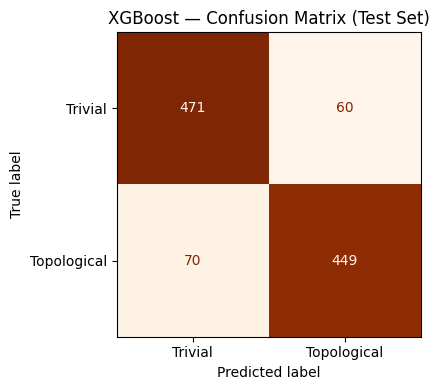

In [ ]:
# ---------------------------------------------------------------
# Evaluate XGBoost on Validation and Test sets
# ---------------------------------------------------------------
y_val_pred_xgb  = xgb_model.predict(X_val)
y_val_prob_xgb  = xgb_model.predict_proba(X_val)[:, 1]

val_acc_xgb = accuracy_score(y_val, y_val_pred_xgb)
val_f1_xgb  = f1_score(y_val, y_val_pred_xgb)
val_auc_xgb = roc_auc_score(y_val, y_val_prob_xgb)

print(f"--- XGBoost Validation ---")
print(f"  Accuracy : {val_acc_xgb:.4f}")
print(f"  F1-score : {val_f1_xgb:.4f}")
print(f"  ROC-AUC  : {val_auc_xgb:.4f}")

y_test_pred_xgb = xgb_model.predict(X_test)
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_f1_xgb  = f1_score(y_test, y_test_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_prob_xgb)

print(f"\n--- XGBoost Test ---")
print(f"  Accuracy : {test_acc_xgb:.4f}")
print(f"  F1-score : {test_f1_xgb:.4f}")
print(f"  ROC-AUC  : {test_auc_xgb:.4f}")
print("\nDetailed Classification Report (Test):")
print(classification_report(y_test, y_test_pred_xgb,
                            target_names=['Trivial', 'Topological']))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(cm_xgb,
                                   display_labels=['Trivial', 'Topological'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_xgb.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('XGBoost — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## Step 11 — SHAP Interpretation for XGBoost

We apply the same five SHAP plot types to XGBoost. Because SHAP's `TreeExplainer` is built for
tree-based models, it computes exact Shapley values very quickly even for large datasets.

XGBoost SHAP values shape: (4900, 12)
--- XGBoost SHAP Beeswarm ---


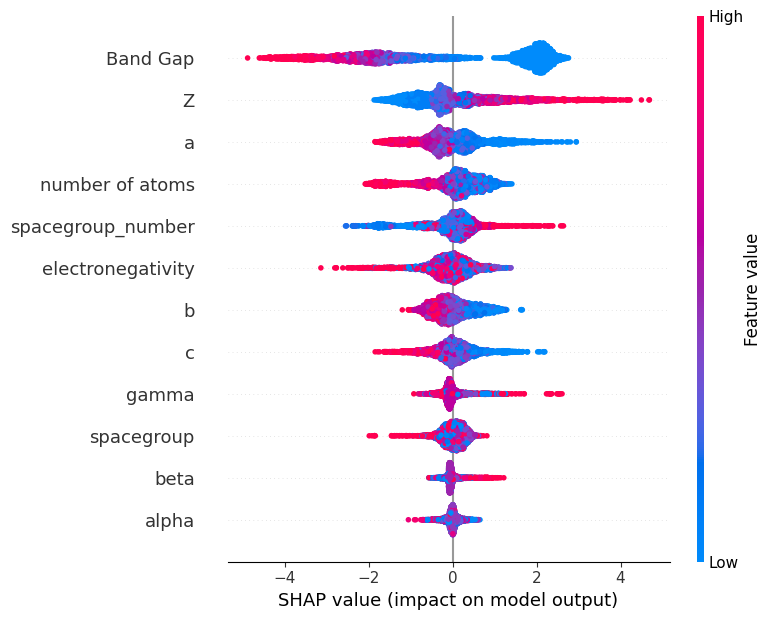

--- XGBoost SHAP Bar Plot ---


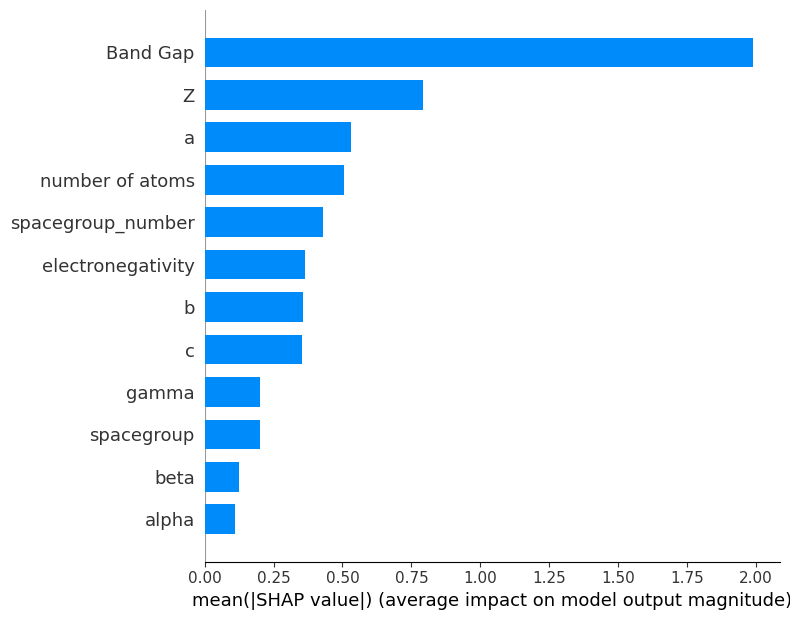

In [ ]:
# ---------------------------------------------------------------
# Create SHAP TreeExplainer for XGBoost
# ---------------------------------------------------------------
xgb_explainer  = shap.TreeExplainer(xgb_model)
shap_vals_xgb  = xgb_explainer.shap_values(X_train)

# For XGBoost binary classifier shap_values is a single array [n, f]
sv_xgb = shap_vals_xgb
print("XGBoost SHAP values shape:", sv_xgb.shape)

# ---------------------------------------------------------------
# Plot 1: Beeswarm Summary Plot
# ---------------------------------------------------------------
print("--- XGBoost SHAP Beeswarm ---")
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_xgb, X_train, feature_names=FEATURES,
                  plot_type='dot', show=True)

# ---------------------------------------------------------------
# Plot 2: Bar Plot
# ---------------------------------------------------------------
print("--- XGBoost SHAP Bar Plot ---")
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_xgb, X_train, feature_names=FEATURES,
                  plot_type='bar', show=True)

--- XGBoost SHAP Waterfall Plots ---


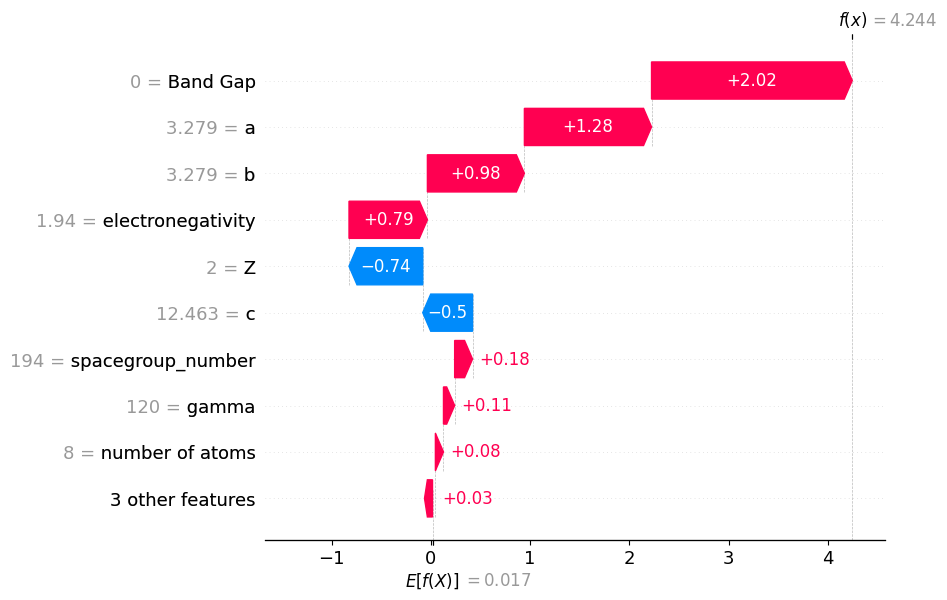

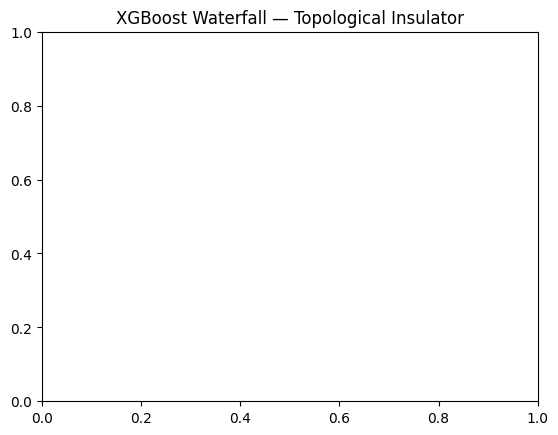

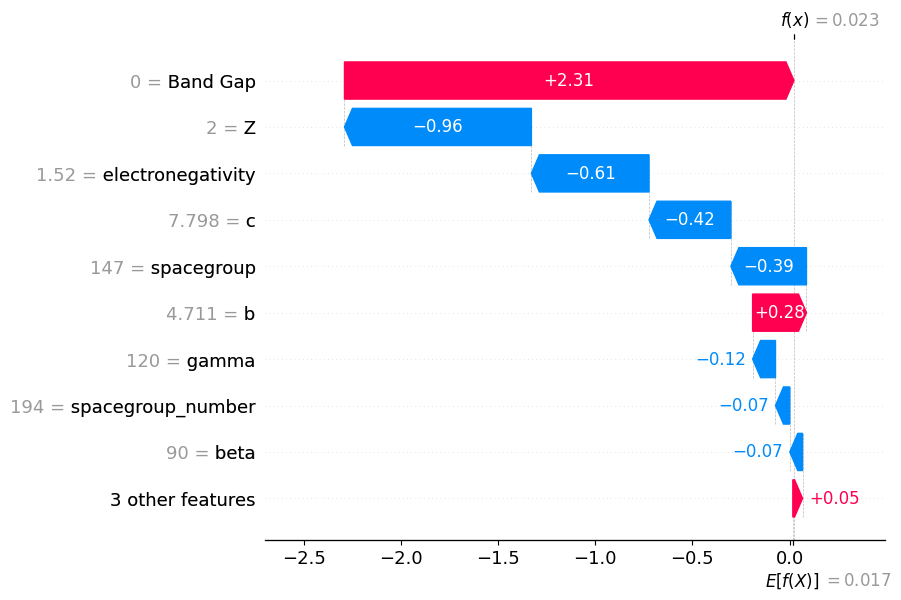

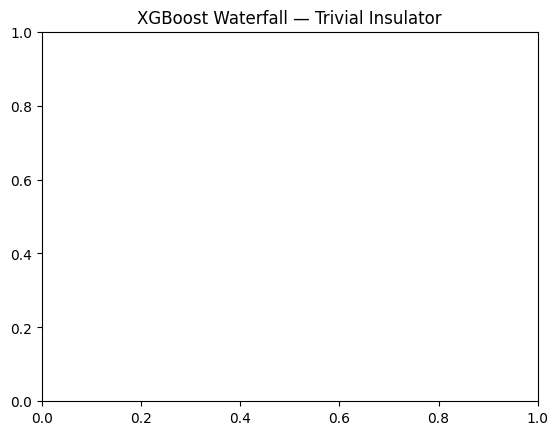

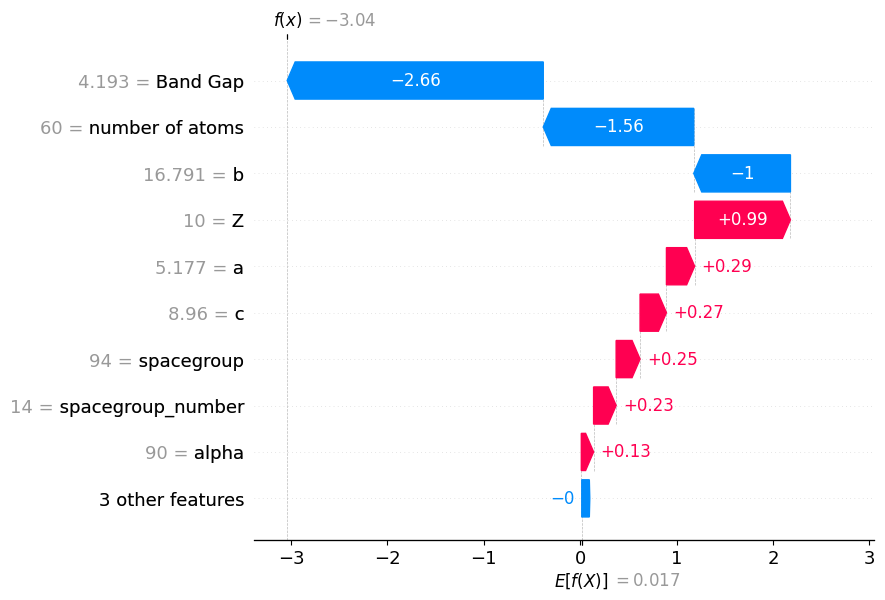

--- XGBoost SHAP Force Plots ---


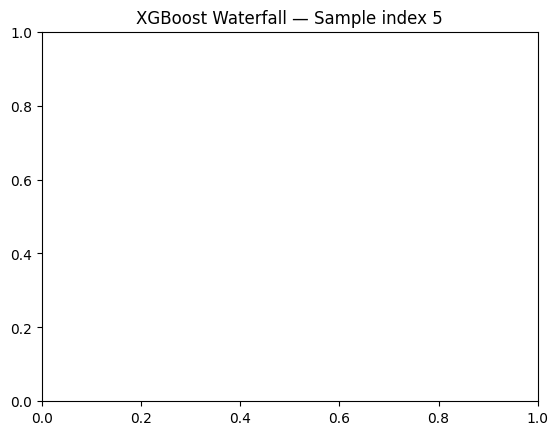

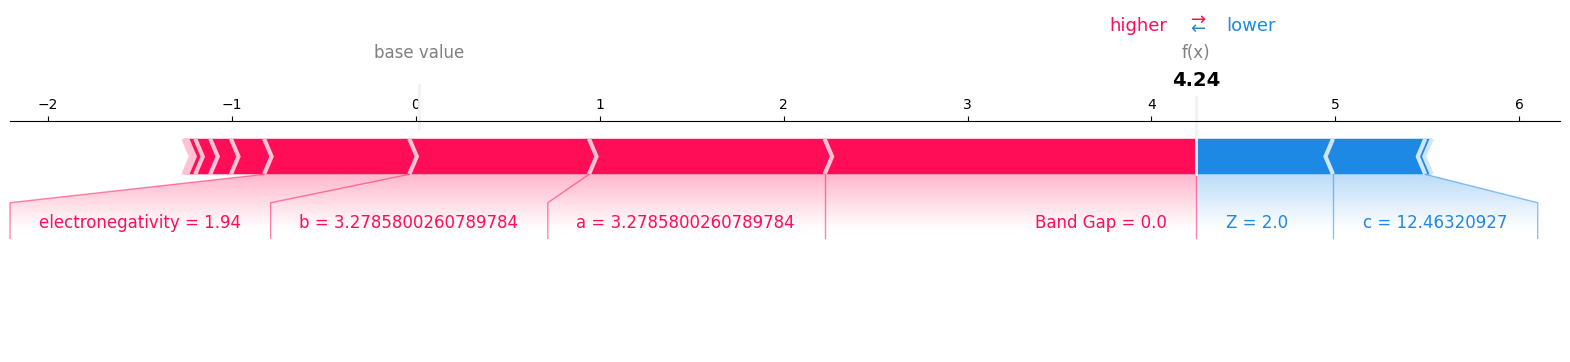

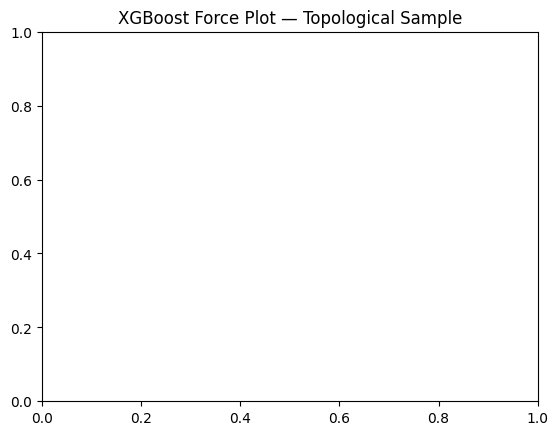

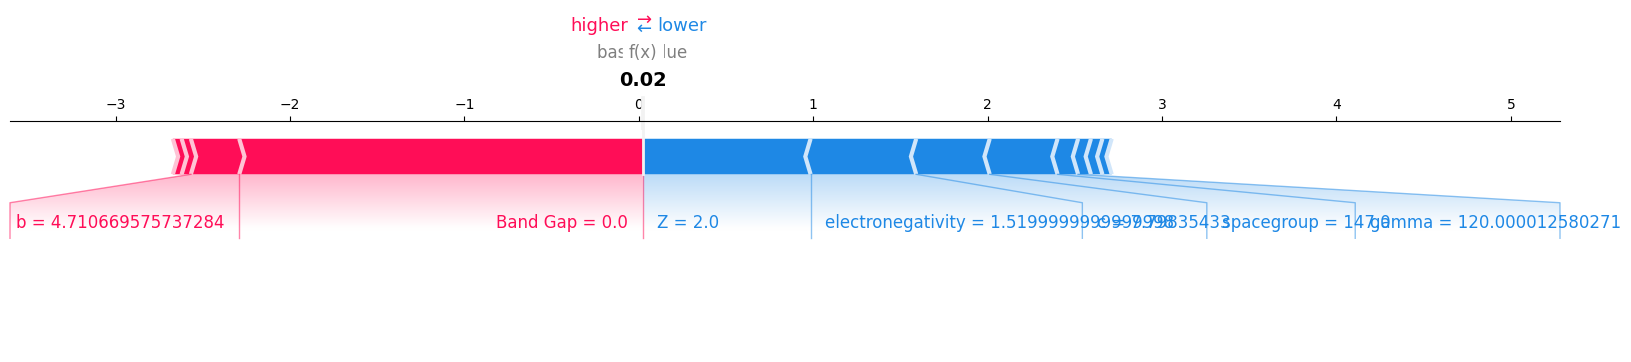

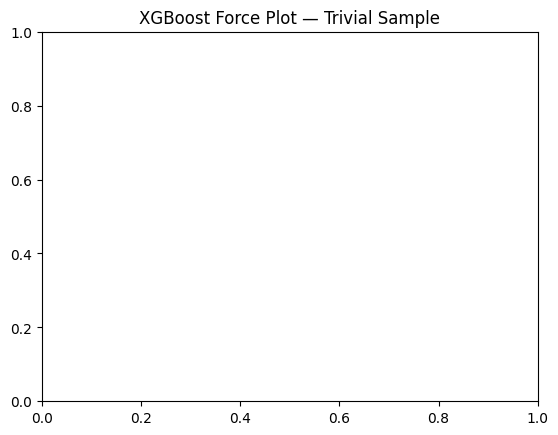

--- XGBoost SHAP Dependence Plots ---


<Figure size 700x500 with 0 Axes>

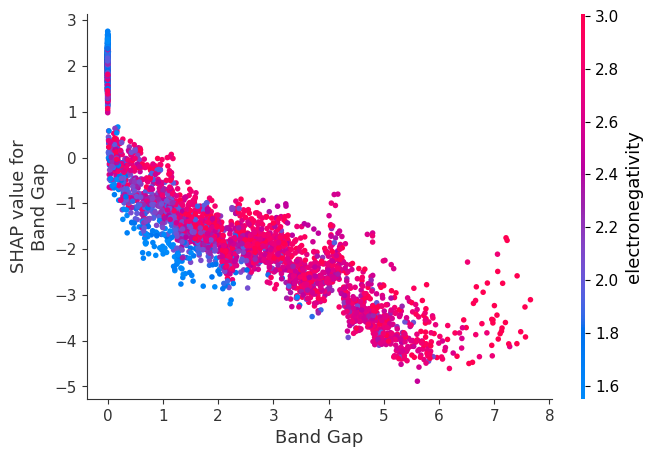

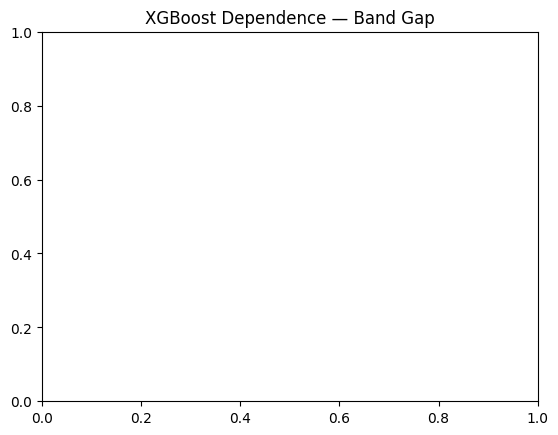

<Figure size 700x500 with 0 Axes>

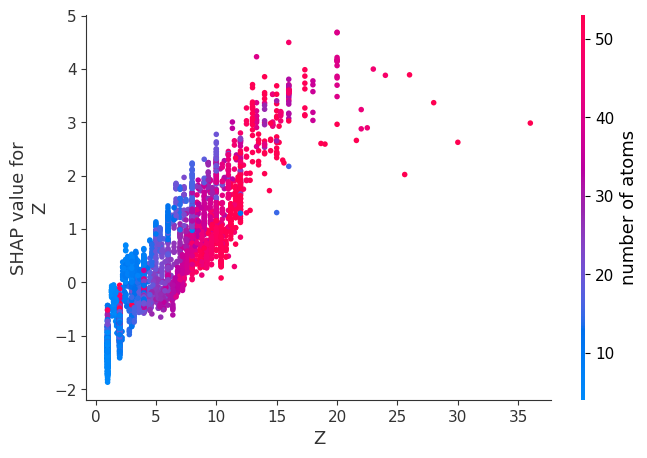

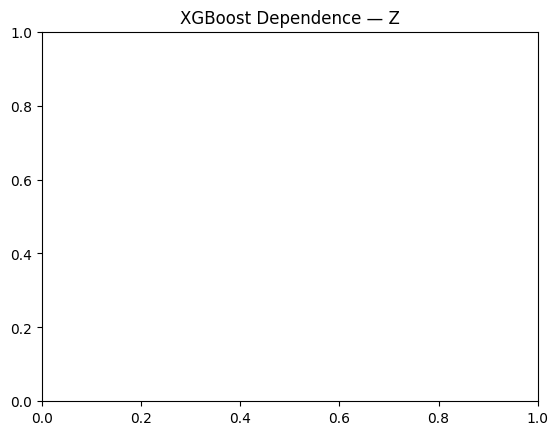

<Figure size 700x500 with 0 Axes>

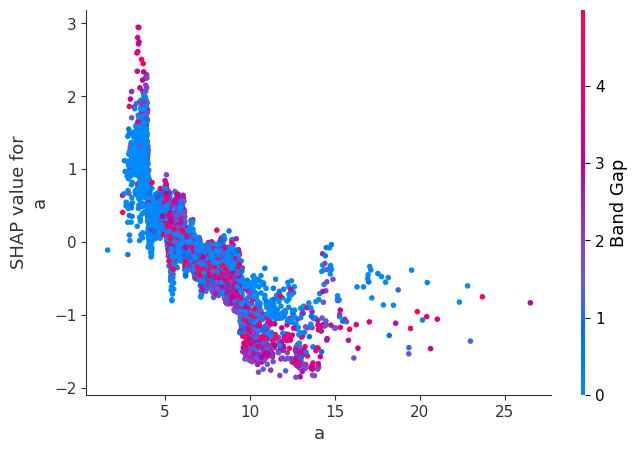

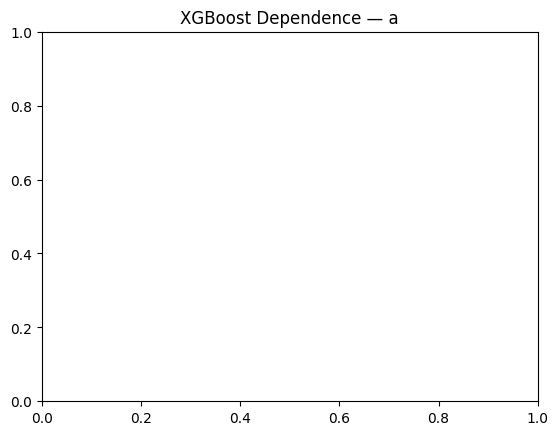

In [ ]:
# ---------------------------------------------------------------
# Build Explanation object for waterfall and force plots
# ---------------------------------------------------------------
xgb_explanation = shap.Explanation(
    values       = sv_xgb,
    base_values  = xgb_explainer.expected_value,
    data         = X_train.values,
    feature_names= FEATURES
)

# ---------------------------------------------------------------
# Plot 3: Waterfall Plots for 3 samples
# ---------------------------------------------------------------
print("--- XGBoost SHAP Waterfall Plots ---")
for pos, label_str in [(ti_pos, 'Topological Insulator'),
                        (trv_pos, 'Trivial Insulator'),
                        (5, 'Sample index 5')]:
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(xgb_explanation[pos], show=True)
    plt.title(f'XGBoost Waterfall — {label_str}')

# ---------------------------------------------------------------
# Plot 4: Force Plots for individual predictions
# ---------------------------------------------------------------
print("--- XGBoost SHAP Force Plots ---")
shap.force_plot(
    base_value   = xgb_explainer.expected_value,
    shap_values  = sv_xgb[ti_pos],
    features     = X_train.iloc[ti_pos],
    feature_names= FEATURES,
    matplotlib   = True
)
plt.title('XGBoost Force Plot — Topological Sample')
plt.show()

shap.force_plot(
    base_value   = xgb_explainer.expected_value,
    shap_values  = sv_xgb[trv_pos],
    features     = X_train.iloc[trv_pos],
    feature_names= FEATURES,
    matplotlib   = True
)
plt.title('XGBoost Force Plot — Trivial Sample')
plt.show()

# ---------------------------------------------------------------
# Plot 5: Dependence Plots for top 3 features
# ---------------------------------------------------------------
print("--- XGBoost SHAP Dependence Plots ---")
mean_shap_xgb = np.abs(sv_xgb).mean(axis=0)
top3_xgb      = np.argsort(mean_shap_xgb)[::-1][:3]

for idx in top3_xgb:
    plt.figure(figsize=(7, 5))
    shap.dependence_plot(
        ind          = idx,
        shap_values  = sv_xgb,
        features     = X_train.values,
        feature_names= FEATURES,
        interaction_index= 'auto',
        show         = True
    )
    plt.title(f'XGBoost Dependence — {FEATURES[idx]}')
    plt.show()

## Step 12 — Build Crystal Graphs from CIF Files

For the GNN models, each material is represented as a **crystal graph**:
- **Nodes** = atoms. Node features = `[atomic number Z, Pauling electronegativity X]` (2-dim vector)
- **Edges** = atom pairs within a 5 Å radius cutoff. Edge feature = interatomic distance (1-dim)
- **Global** `u` = the 11 numeric descriptors (same as tabular features but excluding the string spacegroup)
- **Label** `y` = 0 or 1 (Trivial / TI)
- **Positions** `pos` = Cartesian coordinates (used for attention heatmap visualisation)

We parse CIF files using `pymatgen.CifParser` (Ong et al., 2013).
We build edges using `torch_cluster.radius_graph` which efficiently finds all atom pairs within cutoff r.

**Global feature vector (11 dims):**
`spacegroup_number, number_of_atoms, Band_Gap, a, b, c, alpha, beta, gamma, Z, electronegativity`

Note: We use `spacegroup_number` (integer) rather than the string `spacegroup` in the global vector,
since neural networks require numeric inputs.

In [ ]:
# ---------------------------------------------------------------
# Global feature columns used in the GNN (11 numeric features)
# NOTE: we use spacegroup_number (int) here, NOT the string spacegroup
# ---------------------------------------------------------------
GLOBAL_FEATURES = [
    'spacegroup_number',   # integer space group (1–230)
    'number of atoms',     # atoms per unit cell
    'Band Gap',            # band gap in eV
    'a', 'b', 'c',         # lattice constants (Angstroms)
    'alpha', 'beta', 'gamma',  # lattice angles (degrees)
    'Z',                   # mean atomic number
    'electronegativity'    # mean Pauling electronegativity
]
N_GLOBAL = len(GLOBAL_FEATURES)   # = 11
print(f"Number of global features: {N_GLOBAL}")

# ---------------------------------------------------------------
# Function: build_graph
# Input:  one row from df_model DataFrame
# Output: torch_geometric.data.Data object
#
# Based on CGCNN approach (Xie & Grossman 2018):
#   - atom node features: Z and electronegativity
#   - edges: all pairs within 5 Å cutoff
#   - edge feature: distance
#   - global: table-level descriptors
# ---------------------------------------------------------------
def build_graph(row, cif_base=CIF_BASE, cutoff=5.0):
    """
    Parse a CIF file and convert to a PyTorch Geometric Data object.

    Args:
        row      : one row of df_model (pandas Series)
        cif_base : base directory where cif_files/ folder lives
        cutoff   : neighbour cutoff radius in Angstrom (default 5.0 Å)

    Returns:
        data : torch_geometric.data.Data with fields
               x        — node features [N_atoms, 2]
               edge_index — COO edge list [2, E]
               edge_attr  — edge features (distances) [E, 1]
               u          — global features [1, 11]
               y          — label [1,]
               pos        — Cartesian coordinates [N_atoms, 3]
    """
    # ---- Parse CIF ----
    # row['cif'] is e.g. 'cif_files/mp-331.cif'
    # We join with cif_base to get the absolute path
    cif_rel  = row['cif']                              # relative path from CSV
    cif_path = os.path.join(cif_base, cif_rel)         # absolute path

    # CifParser reads the .cif file and returns pymatgen Structure objects
    parser    = CifParser(cif_path)
    structure = parser.get_structures()[0]              # get first structure

    # ---- Node features ----
    # For each atomic site in the structure extract:
    #   Z = atomic number (e.g. Si=14, Bi=83)
    #   X = Pauling electronegativity (if missing default to 0)
    atom_Z   = [float(site.specie.Z)
                for site in structure]
    atom_X   = [float(site.specie.X) if site.specie.X is not None else 0.0
                for site in structure]

    # Stack into [N_atoms, 2] tensor
    x = torch.tensor(list(zip(atom_Z, atom_X)), dtype=torch.float)

    # ---- Atomic positions (Cartesian coordinates) ----
    # Used by radius_graph and for attention visualisation
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)  # [N, 3]

    # ---- Edge construction via radius_graph ----
    # radius_graph returns all pairs (i, j) where dist(i,j) < cutoff
    # loop=False excludes self-loops
    edge_index = radius_graph(pos, r=cutoff, loop=False)   # [2, E]

    # ---- Edge features: interatomic distances ----
    src, dst = edge_index                         # source and destination atom indices
    # Euclidean distance between each connected pair
    edge_attr = torch.norm(pos[src] - pos[dst],
                           dim=1, keepdim=True)   # [E, 1]

    # ---- Global features vector u ----
    # 11 numeric descriptors from the DataFrame row
    global_vals = [float(row[c]) for c in GLOBAL_FEATURES]
    u = torch.tensor(global_vals, dtype=torch.float).unsqueeze(0)  # [1, 11]

    # ---- Label ----
    y = torch.tensor([int(row['label'])], dtype=torch.long)   # [1,]

    # ---- Build Data object ----
    data = Data(
        x          = x,           # node features [N, 2]
        edge_index = edge_index,   # edge list     [2, E]
        edge_attr  = edge_attr,    # edge features [E, 1]
        u          = u,            # global feats  [1, 11]
        y          = y,            # label         [1,]
        pos        = pos           # coordinates   [N, 3] (for visualisation)
    )
    return data

# ---- Quick sanity check on first training sample ----
sample = build_graph(df_train.iloc[0])
print("Sample graph:")
print(f"  Atoms (nodes)     : {sample.x.shape}")
print(f"  Edges             : {sample.edge_index.shape}")
print(f"  Edge features     : {sample.edge_attr.shape}")
print(f"  Global features u : {sample.u.shape}")
print(f"  Label y           : {sample.y.item()}")
print(f"  Positions         : {sample.pos.shape}")

Number of global features: 11
Sample graph:
  Atoms (nodes)     : torch.Size([8, 2])
  Edges             : torch.Size([2, 30])
  Edge features     : torch.Size([30, 1])
  Global features u : torch.Size([1, 11])
  Label y           : 1
  Positions         : torch.Size([8, 3])


### Build PyTorch Geometric Dataset Objects

We wrap the `build_graph` function in a PyTorch Geometric `Dataset` class. The `DataLoader` then
batches multiple graphs together during training, correctly handling variable numbers of atoms per graph.

In [ ]:
# ---------------------------------------------------------------
# CrystalDataset: wraps a DataFrame of CIF rows into a PyG Dataset
# Inherits from torch_geometric.data.Dataset
# len() returns number of materials
# get(idx) builds the graph for that material on-the-fly
# ---------------------------------------------------------------
class CrystalDataset(Dataset):
    def __init__(self, df, cif_base=CIF_BASE):
        super().__init__()
        self.df       = df.reset_index(drop=True)  # reset index for iloc access
        self.cif_base = cif_base

    def len(self):
        """Return total number of graphs in this split."""
        return len(self.df)

    def get(self, idx):
        """Build and return graph for material at position idx."""
        return build_graph(self.df.iloc[idx], cif_base=self.cif_base)


# ---------------------------------------------------------------
# Build train / val / test datasets
# ---------------------------------------------------------------
print("Building crystal graph datasets... (this may take a few minutes)")

train_dataset = CrystalDataset(df_train)
val_dataset   = CrystalDataset(df_val)
test_dataset  = CrystalDataset(df_test)

print(f"Train graphs : {len(train_dataset)}")
print(f"Val graphs   : {len(val_dataset)}")
print(f"Test graphs  : {len(test_dataset)}")

# ---------------------------------------------------------------
# Create DataLoaders
# DataLoader batches multiple graphs: node features are stacked,
# edge_index is offset per graph, u is stacked [batch, 11]
# ---------------------------------------------------------------
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

# Check one batch
batch_sample = next(iter(train_loader))
print(f"\nSample batch: {batch_sample}")
print(f"  Batch.x shape   : {batch_sample.x.shape}")      # [total_atoms, 2]
print(f"  Batch.u shape   : {batch_sample.u.shape}")      # [32, 11]
print(f"  Batch.y shape   : {batch_sample.y.shape}")      # [32,]

Building crystal graph datasets... (this may take a few minutes)
Train graphs : 4900
Val graphs   : 1050
Test graphs  : 1050

Batch size: 32
Train batches: 154
Val batches  : 33
Test batches : 33

Sample batch: DataBatch(x=[757, 2], edge_index=[2, 9534], edge_attr=[9534, 1], y=[32], pos=[757, 3], u=[32, 11], batch=[757], ptr=[33])
  Batch.x shape   : torch.Size([757, 2])
  Batch.u shape   : torch.Size([32, 11])
  Batch.y shape   : torch.Size([32])


## Step 13 — Charles CGCNN Model Definition

**CharlesCGCNN** is our implementation of the Crystal Graph Convolutional Neural Network
(Xie & Grossman, 2018).

**Architecture:**
1. Two `CGConv` layers (PyG implementation of CGCNN convolution)
2. `ReLU` activation after each layer
3. `global_mean_pool` to aggregate atom-level embeddings into a graph-level vector
4. Concatenate the 11-dim global feature vector `u`
5. Final `Linear` layer → 2-class output (Trivial vs Topological)

**CGConv update rule** (Xie & Grossman 2018, Eq. 5):
```
x_i' = x_i + Σ_{j∈N(i)} σ(z_ij W_f + b_f) ⊙ g(z_ij W_s + b_s)
where z_ij = [x_i, x_j, e_ij]  (concat of atom i, atom j, bond features)
```

Reference: T. Xie & J. C. Grossman, Phys. Rev. Lett. 120, 145301 (2018)
PyG CGConv docs: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.CGConv.html

In [ ]:
# ---------------------------------------------------------------
# CharlesCGCNN — Crystal Graph Convolutional Neural Network
#
# Architecture follows Xie & Grossman (2018):
#   - CGConv layer 1: input (2) → hidden (64)
#   - CGConv layer 2: hidden (64) → hidden (64)
#   - global_mean_pool: aggregate N atoms → 1 graph vector
#   - Concatenate global u (11 dims)
#   - Linear: (64+11) → 2 classes
# ---------------------------------------------------------------
class CharlesCGCNN(nn.Module):
    def __init__(self,
                 node_feat_dim = 2,    # [Z, electronegativity]
                 edge_feat_dim = 1,    # [interatomic distance]
                 hidden_dim    = 64,   # hidden channel width
                 global_dim    = 11,   # length of u vector
                 num_classes   = 2):   # TI vs Trivial
        super().__init__()

        # CGConv layer 1: maps node features from 2-dim to hidden_dim
        # channels=(in, out) defines input and output node feature dims
        # dim=edge_feat_dim tells CGConv the size of edge features
        self.conv1 = CGConv(channels=(node_feat_dim, hidden_dim),
                            dim=edge_feat_dim)

        # CGConv layer 2: keeps node features at hidden_dim
        self.conv2 = CGConv(channels=(hidden_dim, hidden_dim),
                            dim=edge_feat_dim)

        # Batch normalisation after each convolution layer for stable training
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # Final classification layer
        # Input = pooled atom embedding (hidden_dim) + global features (global_dim)
        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data):
        """
        Forward pass through the Charles CGCNN.

        Args:
            data: batched PyG Data with x, edge_index, edge_attr, batch, u
        Returns:
            logits: [batch_size, 2] — raw scores for each class
        """
        # Unpack graph components
        x         = data.x           # [total_atoms, 2]
        edge_index = data.edge_index  # [2, total_edges]
        edge_attr  = data.edge_attr   # [total_edges, 1]
        batch      = data.batch       # [total_atoms,] — maps atom to graph
        u          = data.u           # [batch_size, 11]

        # ---- Message Passing Layer 1 ----
        # CGConv aggregates neighbour info: each atom gathers info from
        # its bonded neighbours within the 5 Å cutoff
        x = self.conv1(x, edge_index, edge_attr)   # [total_atoms, hidden_dim]
        x = self.bn1(x)
        x = F.relu(x)                               # non-linearity

        # ---- Message Passing Layer 2 ----
        x = self.conv2(x, edge_index, edge_attr)   # [total_atoms, hidden_dim]
        x = self.bn2(x)
        x = F.relu(x)

        # ---- Global Mean Pooling ----
        # Average all atom embeddings in each graph → one vector per crystal
        x = global_mean_pool(x, batch)             # [batch_size, hidden_dim]

        # ---- Concatenate Global Features ----
        # Append lattice/electronic descriptors from the table
        # u has shape [batch_size, 11]
        out = torch.cat([x, u], dim=1)             # [batch_size, hidden_dim+11]

        # ---- Classification ----
        out = self.fc(out)                         # [batch_size, 2]
        return out


# ---- Instantiate the model ----
torch.manual_seed(42)
charles_cgcnn = CharlesCGCNN(
    node_feat_dim = 2,
    edge_feat_dim = 1,
    hidden_dim    = 64,
    global_dim    = N_GLOBAL,   # 11
    num_classes   = 2
).to(device)

print("Charles CGCNN Architecture:")
print(charles_cgcnn)
total_params = sum(p.numel() for p in charles_cgcnn.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Charles CGCNN Architecture:
CharlesCGCNN(
  (conv1): CGConv((2, 64), dim=1)
  (conv2): CGConv((64, 64), dim=1)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=75, out_features=2, bias=True)
)

Total trainable parameters: 25,752


## Step 14 — Train Charles CGCNN

We train the Charles model using:
- **Loss**: Cross-Entropy (suitable for multi-class classification)
- **Optimizer**: Adam (lr=1e-3, weight_decay=1e-5) — standard for GNNs
- **Epochs**: 50 (increase for better performance)
- We print validation metrics (Accuracy, F1, ROC-AUC) after each epoch

Reference: Standard GNN training loop as in Fey & Lenssen (2019) PyG paper.

In [ ]:
# ── Diagnostic cell ─────────────────────────────────────────────────────────
# Run this BEFORE redefining the model.
# It prints the shapes of every component in a single training batch.

sample_batch = next(iter(train_loader))
sample_batch = sample_batch.to(device)

print("=== Batch shape diagnostics ===")
print(f"  batch.x shape        : {sample_batch.x.shape}")
# Expected: [total_atoms_in_batch, 2]  e.g. [7004, 2]

print(f"  batch.edge_index     : {sample_batch.edge_index.shape}")
# Expected: [2, total_edges]

print(f"  batch.edge_attr      : {sample_batch.edge_attr.shape}")
# Expected: [total_edges, 1]

print(f"  batch.u shape        : {sample_batch.u.shape}")
# Expected: [32, 11]  (batch_size × global_features)

print(f"  batch.y shape        : {sample_batch.y.shape}")
# Expected: [32]  (one label per graph)

print(f"  batch.batch shape    : {sample_batch.batch.shape}")
# Expected: [total_atoms]  — maps each atom to its graph index

print(f"  num graphs in batch  : {sample_batch.num_graphs}")
# Expected: 32

# Derived values used to instantiate the model
NODE_FEAT_DIM = sample_batch.x.shape[1]    # should be 2
EDGE_FEAT_DIM = sample_batch.edge_attr.shape[1]  # should be 1
GLOBAL_DIM    = sample_batch.u.shape[1]    # should be 11

print(f"\n=== Derived model dimensions ===")
print(f"  NODE_FEAT_DIM = {NODE_FEAT_DIM}")
print(f"  EDGE_FEAT_DIM = {EDGE_FEAT_DIM}")
print(f"  GLOBAL_DIM    = {GLOBAL_DIM}")
print("\nIf any of these look wrong, fix build_graph() before proceeding.")

=== Batch shape diagnostics ===
  batch.x shape        : torch.Size([616, 2])
  batch.edge_index     : torch.Size([2, 7004])
  batch.edge_attr      : torch.Size([7004, 1])
  batch.u shape        : torch.Size([32, 11])
  batch.y shape        : torch.Size([32])
  batch.batch shape    : torch.Size([616])
  num graphs in batch  : 32

=== Derived model dimensions ===
  NODE_FEAT_DIM = 2
  EDGE_FEAT_DIM = 1
  GLOBAL_DIM    = 11

If any of these look wrong, fix build_graph() before proceeding.


In [ ]:
# ── Diagnostic cell ─────────────────────────────────────────────────────────
# Run this BEFORE redefining the model.
# It prints the shapes of every component in a single training batch.

sample_batch = next(iter(train_loader))
sample_batch = sample_batch.to(device)

print("=== Batch shape diagnostics ===")
print(f"  batch.x shape        : {sample_batch.x.shape}")
# Expected: [total_atoms_in_batch, 2]  e.g. [7004, 2]

print(f"  batch.edge_index     : {sample_batch.edge_index.shape}")
# Expected: [2, total_edges]

print(f"  batch.edge_attr      : {sample_batch.edge_attr.shape}")
# Expected: [total_edges, 1]

print(f"  batch.u shape        : {sample_batch.u.shape}")
# Expected: [32, 11]  (batch_size × global_features)

print(f"  batch.y shape        : {sample_batch.y.shape}")
# Expected: [32]  (one label per graph)

print(f"  batch.batch shape    : {sample_batch.batch.shape}")
# Expected: [total_atoms]  — maps each atom to its graph index

print(f"  num graphs in batch  : {sample_batch.num_graphs}")
# Expected: 32

# Derived values used to instantiate the model
NODE_FEAT_DIM = sample_batch.x.shape[1]    # should be 2
EDGE_FEAT_DIM = sample_batch.edge_attr.shape[1]  # should be 1
GLOBAL_DIM    = sample_batch.u.shape[1]    # should be 11

print(f"\n=== Derived model dimensions ===")
print(f"  NODE_FEAT_DIM = {NODE_FEAT_DIM}")
print(f"  EDGE_FEAT_DIM = {EDGE_FEAT_DIM}")
print(f"  GLOBAL_DIM    = {GLOBAL_DIM}")
print("\nIf any of these look wrong, fix build_graph() before proceeding.")

=== Batch shape diagnostics ===
  batch.x shape        : torch.Size([669, 2])
  batch.edge_index     : torch.Size([2, 7742])
  batch.edge_attr      : torch.Size([7742, 1])
  batch.u shape        : torch.Size([32, 11])
  batch.y shape        : torch.Size([32])
  batch.batch shape    : torch.Size([669])
  num graphs in batch  : 32

=== Derived model dimensions ===
  NODE_FEAT_DIM = 2
  EDGE_FEAT_DIM = 1
  GLOBAL_DIM    = 11

If any of these look wrong, fix build_graph() before proceeding.


In [ ]:
# Run this cell to see EXACTLY where the shape breaks.
# We add print() inside a debug version of forward().

import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool

class CharlesCGCNN_DEBUG(nn.Module):
    """
    Identical to CharlesCGCNN but with print() at every step.
    Run ONE batch through this to see where the shape goes wrong.
    """
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 hidden_dim=64, global_dim=11, num_classes=2):
        super().__init__()
        # ── THE KEY CHANGE ──────────────────────────────────────────────────
        # CGConv with an INTEGER for channels keeps in_dim == out_dim.
        # To go from 2-dim atom features to 64-dim we need ONE Linear first.
        # This is exactly what the original CGCNN paper (Xie & Grossman 2018)
        # calls the "atom feature vector initialisation layer".
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)  # 2 → 64
        # Now both conv layers use integer channels — in = out = hidden_dim
        self.conv1 = CGConv(hidden_dim, dim=edge_feat_dim)     # 64 → 64
        self.conv2 = CGConv(hidden_dim, dim=edge_feat_dim)     # 64 → 64
        self.fc    = nn.Linear(hidden_dim + global_dim, num_classes)  # 75 → 2

    def forward(self, data):
        x, ei, ea, batch, u = (data.x, data.edge_index,
                                data.edge_attr, data.batch, data.u)
        if u.dim() == 3: u = u.squeeze(1)   # [B,1,11] → [B,11]

        print(f"  [0] x after load       : {x.shape}")   # [N, 2]
        x = F.relu(self.node_emb(x))
        print(f"  [1] x after node_emb   : {x.shape}")   # [N, 64]
        x = F.relu(self.conv1(x, ei, ea))
        print(f"  [2] x after conv1      : {x.shape}")   # [N, 64]
        x = F.relu(self.conv2(x, ei, ea))
        print(f"  [3] x after conv2      : {x.shape}")   # [N, 64]
        x = global_mean_pool(x, batch)
        print(f"  [4] x after pool       : {x.shape}")   # [B, 64]
        print(f"  [5] u                  : {u.shape}")    # [B, 11]
        out = torch.cat([x, u], dim=1)
        print(f"  [6] out after cat      : {out.shape}")  # [B, 75]
        out = self.fc(out)
        print(f"  [7] out after fc       : {out.shape}")  # [B, 2]
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dbg = CharlesCGCNN_DEBUG().to(device)
dbg.eval()

sample = next(iter(train_loader)).to(device)
print("=== Debug forward pass ===")
with torch.no_grad():
    out = dbg(sample)
print(f"\nFinal output shape: {out.shape}  ← should be [{sample.num_graphs}, 2]")

=== Debug forward pass ===
  [0] x after load       : torch.Size([740, 2])
  [1] x after node_emb   : torch.Size([740, 64])
  [2] x after conv1      : torch.Size([740, 64])
  [3] x after conv2      : torch.Size([740, 64])
  [4] x after pool       : torch.Size([32, 64])
  [5] u                  : torch.Size([32, 11])
  [6] out after cat      : torch.Size([32, 75])
  [7] out after fc       : torch.Size([32, 2])

Final output shape: torch.Size([32, 2])  ← should be [32, 2]


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import os

class CharlesCGCNN(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 hidden_dim=64, global_dim=11, num_classes=2):
        super().__init__()
        # Step 1: embed raw atom features [Z, EN] into hidden_dim space
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)
        # Step 2: two CGConv message-passing layers at hidden_dim
        self.conv1 = CGConv(hidden_dim, dim=edge_feat_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_feat_dim)
        # Step 3: classify from (pooled_graph_embed + global_features)
        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data):
        x, ei, ea, batch, u = (data.x, data.edge_index,
                                data.edge_attr, data.batch, data.u)
        if u.dim() == 3: u = u.squeeze(1)   # guard for [B,1,11] edge case
        # atom embedding
        x = F.relu(self.node_emb(x))         # [N_atoms, 64]
        # message passing — each atom learns from its bonded neighbours
        x = F.relu(self.conv1(x, ei, ea))    # [N_atoms, 64]
        x = F.relu(self.conv2(x, ei, ea))    # [N_atoms, 64]
        # pool all atoms in each crystal into one vector
        x = global_mean_pool(x, batch)       # [B, 64]
        # append global (lattice / electronic) descriptors
        out = torch.cat([x, u], dim=1)       # [B, 75]
        return self.fc(out)                  # [B, 2]

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
charles_cgcnn = CharlesCGCNN(
    node_feat_dim=2, edge_feat_dim=1,
    hidden_dim=64, global_dim=N_GLOBAL, num_classes=2
).to(device)

# ── Quick shape sanity check ───────────────────────────────────────────────────
charles_cgcnn.eval()
with torch.no_grad():
    s = next(iter(train_loader)).to(device)
    out = charles_cgcnn(s)
print(f"Forward pass OK: input atoms {s.x.shape} → output {out.shape}")
# Expect: output torch.Size([32, 2])
n = sum(p.numel() for p in charles_cgcnn.parameters() if p.requires_grad)
print(f"Total parameters: {n:,}")

Forward pass OK: input atoms torch.Size([746, 2]) → output torch.Size([32, 2])
Total parameters: 33,624


In [ ]:
cgcnn_optimizer = torch.optim.Adam(
    charles_cgcnn.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()
cgcnn_history = {'train_loss':[], 'val_acc':[], 'val_f1':[], 'val_auc':[]}
NUM_EPOCHS = 50

print(f"Training CharlesCGCNN for {NUM_EPOCHS} epochs on {device}...")
print("-"*65)

for epoch in range(1, NUM_EPOCHS+1):

    # ── train ──────────────────────────────────────────────────────────────
    charles_cgcnn.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        cgcnn_optimizer.zero_grad()
        out  = charles_cgcnn(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        cgcnn_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    avg_loss = total_loss / len(train_dataset)

    # ── validate ────────────────────────────────────────────────────────────
    charles_cgcnn.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out   = charles_cgcnn(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out,dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)
    cgcnn_history['train_loss'].append(avg_loss)
    cgcnn_history['val_acc'].append(acc)
    cgcnn_history['val_f1'].append(f1)
    cgcnn_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Val Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# ── test ────────────────────────────────────────────────────────────────────
charles_cgcnn.eval()
tp, tprob, tlab = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = charles_cgcnn(batch)
        tp.extend(out.argmax(dim=1).cpu().numpy())
        tprob.extend(torch.softmax(out,dim=1)[:,1].cpu().numpy())
        tlab.extend(batch.y.cpu().numpy())

print("\n=== CharlesCGCNN — TEST SET ===")
print(f"  Accuracy : {accuracy_score(tlab, tp):.4f}")
print(f"  F1-score : {f1_score(tlab, tp):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(tlab, tprob):.4f}")
print(classification_report(tlab, tp, target_names=['Trivial','Topological']))

# save checkpoint to Drive
save_path = os.path.join(BASE_DIR, 'Charles_CGCNN.pth')
torch.save(charles_cgcnn.state_dict(), save_path)
print(f"Saved → {save_path}")

Training CharlesCGCNN for 50 epochs on cuda...
-----------------------------------------------------------------


In [ ]:
from torch_geometric.nn import GATConv, global_mean_pool

class CharlesAttentionGNN(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 hidden_dim=64, heads=4, global_dim=11, num_classes=2):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)   # 2 → 64
        # GAT layer 1: 64 → 64*heads (multi-head, concatenated)
        self.gat1 = GATConv(hidden_dim, hidden_dim,
                             heads=heads, edge_dim=edge_feat_dim, concat=True)
        # GAT layer 2: 64*heads → 64 (single head, averaged)
        self.gat2 = GATConv(hidden_dim*heads, hidden_dim,
                             heads=1, concat=False)
        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data, return_attention=False):
        x, ei, ea, batch, u = (data.x, data.edge_index,
                                data.edge_attr, data.batch, data.u)
        if u.dim() == 3: u = u.squeeze(1)
        x = F.relu(self.node_emb(x))                  # [N, 64]
        if return_attention:
            x, (att_ei, alpha) = self.gat1(
                x, ei, ea, return_attention_weights=True)
        else:
            x = self.gat1(x, ei, ea)
        x = F.elu(x)                                   # [N, 64*heads]
        x = F.elu(self.gat2(x, ei))                    # [N, 64]
        x = global_mean_pool(x, batch)                 # [B, 64]
        out = torch.cat([x, u], dim=1)                 # [B, 75]
        out = self.fc(out)
        if return_attention:
            return out, att_ei, alpha
        return out

torch.manual_seed(42)
charles_attn = CharlesAttentionGNN(
    node_feat_dim=2, edge_feat_dim=1, hidden_dim=64,
    heads=4, global_dim=N_GLOBAL, num_classes=2).to(device)

charles_attn.eval()
with torch.no_grad():
    s = next(iter(train_loader)).to(device)
    o = charles_attn(s)
print(f"AttentionGNN forward OK: {s.x.shape} → {o.shape}")

In [ ]:
# ---------------------------------------------------------------
# Plot training curves
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cgcnn_history['train_loss'], color='steelblue', label='Train Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('CharlesCGCNN — Training Loss'); axes[0].legend()

axes[1].plot(cgcnn_history['val_acc'],  label='Accuracy', color='green')
axes[1].plot(cgcnn_history['val_f1'],   label='F1-score',  color='orange')
axes[1].plot(cgcnn_history['val_auc'],  label='ROC-AUC',   color='red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('CharlesCGCNN — Validation Metrics')
axes[1].legend(); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Final Test evaluation
# ---------------------------------------------------------------
charles_cgcnn.eval()
test_preds_cgcnn, test_probs_cgcnn, test_labels_cgcnn = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = charles_cgcnn(batch)
        pred  = out.argmax(dim=1).cpu().numpy()
        prob  = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        lbl   = batch.y.cpu().numpy()
        test_preds_cgcnn.extend(pred)
        test_probs_cgcnn.extend(prob)
        test_labels_cgcnn.extend(lbl)

cgcnn_test_acc = accuracy_score(test_labels_cgcnn, test_preds_cgcnn)
cgcnn_test_f1  = f1_score(test_labels_cgcnn, test_preds_cgcnn, zero_division=0)
cgcnn_test_auc = roc_auc_score(test_labels_cgcnn, test_probs_cgcnn)

print("=== CharlesCGCNN — TEST SET RESULTS ===")
print(f"  Accuracy : {cgcnn_test_acc:.4f}")
print(f"  F1-score : {cgcnn_test_f1:.4f}")
print(f"  ROC-AUC  : {cgcnn_test_auc:.4f}")
print(classification_report(test_labels_cgcnn, test_preds_cgcnn,
                            target_names=['Trivial', 'Topological']))

# Save the model weights to Google Drive
save_path = os.path.join(BASE_DIR, 'Charles_CGCNN.pth')
torch.save(charles_cgcnn.state_dict(), save_path)
print(f"\nModel saved to: {save_path}")

## Step 15 — CharlesAttentionGNN (GAT-based)

To extract **attention heatmaps** showing which atoms the model focuses on, we replace the `CGConv`
layers with `GATConv` (Graph Attention Network, Velicković et al., 2018).

GATConv computes attention coefficients α_ij for each edge (i→j):
```
α_ij = softmax_j( LeakyReLU( a^T [W h_i ‖ W h_j] ) )
h_i' = σ( Σ_j α_ij W h_j )
```
These attention weights tell us which neighbouring atoms are most important for each atom's update.

We store `return_attention_weights=True` in the forward pass to capture α values.

Reference: P. Velicković et al., ICLR 2018 — https://arxiv.org/abs/1710.10903
PyG GATConv: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html

In [ ]:
# ---------------------------------------------------------------
# CharlesAttentionGNN — GAT-based model for attention heatmaps
#
# Architecture:
#   - GATConv layer 1: 2-dim input → 64 * 4 heads = 256-dim output
#   - GATConv layer 2: 256-dim input → 64-dim (1 head)
#   - global_mean_pool
#   - Concatenate u (11 dims)
#   - Linear: (64+11) → 2 classes
# ---------------------------------------------------------------
class CharlesAttentionGNN(nn.Module):
    def __init__(self,
                 node_feat_dim = 2,
                 edge_feat_dim = 1,
                 hidden_dim    = 64,
                 heads         = 4,    # number of attention heads
                 global_dim    = 11,
                 num_classes   = 2):
        super().__init__()

        # ---- GAT Layer 1 ----
        # Multi-head attention: each head has hidden_dim channels
        # Output = hidden_dim * heads = 64 * 4 = 256
        # edge_dim=edge_feat_dim enables edge features in attention
        # concat=True concatenates attention heads (default)
        self.gat1 = GATConv(
            in_channels  = node_feat_dim,
            out_channels = hidden_dim,
            heads        = heads,
            edge_dim     = edge_feat_dim,
            concat       = True          # concatenate heads → hidden*heads
        )

        # ---- GAT Layer 2 ----
        # Single head to reduce back to hidden_dim
        # concat=False averages over heads
        self.gat2 = GATConv(
            in_channels  = hidden_dim * heads,  # 256
            out_channels = hidden_dim,           # 64
            heads        = 1,
            concat       = False                 # average (not concatenate)
        )

        # Batch norms for stable training
        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # Final classification head
        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data, return_attention=False):
        """
        Forward pass. If return_attention=True, also returns
        the edge_index and attention weights from layer 1 (for heatmaps).
        """
        x          = data.x
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        batch      = data.batch
        u          = data.u

        # ---- GAT Layer 1 ----
        # return_attention_weights='True' makes GATConv return (x, (edge_index, alpha))
        if return_attention:
            x, (att_edge_index, alpha1) = self.gat1(
                x, edge_index, edge_attr,
                return_attention_weights=True   # capture alpha_ij
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)

        x = self.bn1(x)
        x = F.elu(x)    # ELU activation (standard for GAT)

        # ---- GAT Layer 2 ----
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)

        # ---- Pooling + Global concat ----
        x   = global_mean_pool(x, batch)
        out = torch.cat([x, u], dim=1)
        out = self.fc(out)

        if return_attention:
            return out, att_edge_index, alpha1
        return out


# ---- Instantiate ----
torch.manual_seed(42)
charles_attn = CharlesAttentionGNN(
    node_feat_dim = 2,
    edge_feat_dim = 1,
    hidden_dim    = 64,
    heads         = 4,
    global_dim    = N_GLOBAL,
    num_classes   = 2
).to(device)

print("CharlesAttentionGNN:")
print(charles_attn)
attn_params = sum(p.numel() for p in charles_attn.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {attn_params:,}")

In [ ]:
# ---------------------------------------------------------------
# Train CharlesAttentionGNN — same loop as CharlesCGCNN
# ---------------------------------------------------------------
attn_optimizer = torch.optim.Adam(
    charles_attn.parameters(), lr=1e-3, weight_decay=1e-5
)

attn_history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

NUM_EPOCHS_ATTN = 50
print(f"Training CharlesAttentionGNN for {NUM_EPOCHS_ATTN} epochs...")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS_ATTN + 1):

    # ---- Training ----
    charles_attn.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        attn_optimizer.zero_grad()
        out  = charles_attn(batch)                    # standard forward (no attention)
        loss = criterion(out, batch.y)
        loss.backward()
        attn_optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_dataset)

    # ---- Validation ----
    charles_attn.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out   = charles_attn(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    attn_history['train_loss'].append(avg_loss)
    attn_history['val_acc'].append(acc)
    attn_history['val_f1'].append(f1)
    attn_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS_ATTN} | "
              f"Loss: {avg_loss:.4f} | Val Acc: {acc:.4f} | "
              f"F1: {f1:.4f} | AUC: {auc:.4f}")

# ---- Test evaluation ----
charles_attn.eval()
test_preds_attn, test_probs_attn, test_labels_attn = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = charles_attn(batch)
        test_preds_attn.extend(out.argmax(dim=1).cpu().numpy())
        test_probs_attn.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
        test_labels_attn.extend(batch.y.cpu().numpy())

print("\n=== CharlesAttentionGNN — TEST RESULTS ===")
print(f"  Accuracy : {accuracy_score(test_labels_attn, test_preds_attn):.4f}")
print(f"  F1-score : {f1_score(test_labels_attn, test_preds_attn):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(test_labels_attn, test_probs_attn):.4f}")

# Save model
attn_save = os.path.join(BASE_DIR, 'Charles_AttentionGNN.pth')
torch.save(charles_attn.state_dict(), attn_save)
print(f"Saved to: {attn_save}")

## Step 16 — Attention Heatmap Visualisation

After training the GAT model, we extract the attention weights α_ij from the first GATConv layer.
For each atom i, we accumulate the attention it receives from all its neighbours (sum over incoming edges).
This gives an **atomic attention score** per atom.

We then plot the atoms in 2D (x-y plane of Cartesian coordinates), coloured by attention score using
a "hot" colourmap — bright atoms are most attended to. This reveals which atomic sites drive the model's
topological prediction.

Reference: Velicković et al. (2018) — attention mechanisms in GNNs.

In [ ]:
# ---------------------------------------------------------------
# Extract attention heatmap for one crystal from the test set
# ---------------------------------------------------------------
charles_attn.eval()

# Get a single test graph (we iterate and pick a specific label for clarity)
# We'll pick first TI (label=1) from the test set for a clear visualisation
sample_graph = None
for batch in test_loader:
    for i in range(batch.num_graphs):
        # Extract individual graph from batch using PyG utility
        start = (batch.batch == i).nonzero(as_tuple=True)[0][0].item()
        end   = (batch.batch == i).nonzero(as_tuple=True)[0][-1].item() + 1
        if batch.y[i].item() == 1:   # find first TI sample
            # Manually extract single graph data
            mask       = batch.batch == i
            edge_mask  = mask[batch.edge_index[0]]
            local_edge = batch.edge_index[:, edge_mask]
            # Re-index edges locally
            node_offset = mask.nonzero(as_tuple=True)[0][0].item()
            local_edge  = local_edge - node_offset

            sample_graph = Data(
                x          = batch.x[mask],
                edge_index = local_edge,
                edge_attr  = batch.edge_attr[edge_mask],
                u          = batch.u[i:i+1],
                y          = batch.y[i:i+1],
                pos        = batch.pos[mask]
            )
            break
    if sample_graph is not None:
        break

print(f"Selected crystal — nodes: {sample_graph.num_nodes}, "
      f"edges: {sample_graph.num_edges}, label: {sample_graph.y.item()}")

# ---------------------------------------------------------------
# Forward pass with return_attention=True
# ---------------------------------------------------------------
sample_graph = sample_graph.to(device)

with torch.no_grad():
    _, att_edge_index, alpha1 = charles_attn(
        sample_graph, return_attention=True
    )

# alpha1 shape: [num_edges, num_heads]
# Average attention over all heads to get one score per edge
alpha_mean = alpha1.mean(dim=1).cpu().numpy()   # [num_edges,]
edge_idx   = att_edge_index.cpu().numpy()        # [2, num_edges]

# ---------------------------------------------------------------
# Aggregate edge attention to nodes
# For each atom (destination node j), sum incoming attention
# This gives: how much is each atom attended to?
# ---------------------------------------------------------------
n_atoms       = sample_graph.num_nodes
node_attention = np.zeros(n_atoms)

for e, (src, dst) in enumerate(zip(edge_idx[0], edge_idx[1])):
    node_attention[dst] += alpha_mean[e]    # accumulate incoming attention

# Normalise to [0, 1] for clean colour scale
node_attention = (node_attention - node_attention.min()) /                  (node_attention.max() - node_attention.min() + 1e-8)

# ---------------------------------------------------------------
# Get atomic positions (Cartesian) and atomic numbers for labels
# ---------------------------------------------------------------
coords = sample_graph.pos.cpu().numpy()    # [N, 3]
Z_vals = sample_graph.x[:, 0].cpu().numpy()  # atomic numbers

# ---------------------------------------------------------------
# Plot 1: 2D scatter (x-y plane) coloured by attention score
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- XY plane ---
sc = axes[0].scatter(coords[:, 0], coords[:, 1],
                     c=node_attention, cmap='hot',
                     s=200, edgecolors='black', linewidths=0.7)
plt.colorbar(sc, ax=axes[0], label='Attention Score')
# Annotate atoms with their atomic number
for i, (xi, yi, Zi, att) in enumerate(
        zip(coords[:,0], coords[:,1], Z_vals, node_attention)):
    axes[0].annotate(f'Z={int(Zi)}', (xi, yi),
                     textcoords='offset points', xytext=(4, 4),
                     fontsize=7, color='white' if att > 0.6 else 'black')
axes[0].set_xlabel('x (Å)'); axes[0].set_ylabel('y (Å)')
axes[0].set_title('Attention Heatmap — XY Plane\n'
                  '(Bright atoms = high attention)')

# --- Bar chart of per-atom attention ----
atom_labels = [f'Z={int(z)}' for z in Z_vals]
axes[1].barh(range(n_atoms), node_attention,
             color=cm.hot(node_attention))
axes[1].set_yticks(range(n_atoms))
axes[1].set_yticklabels(atom_labels, fontsize=8)
axes[1].set_xlabel('Normalised Attention Score')
axes[1].set_title('Per-Atom Attention Scores')
axes[1].invert_yaxis()

plt.suptitle('CharlesAttentionGNN — Atom Attention Heatmap (TI Sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation: Bright/long bars = atoms the model attends to most.")
print("High attention on heavy atoms (large Z) is physically meaningful —")
print("heavier elements provide stronger spin-orbit coupling, driving topology.")

## Step 17 — CharlesMEGNet Model Definition

**MEGNet** (MatErials Graph Network, Chen et al., 2019) extends standard GNNs by explicitly updating
three types of information at each block:
1. **Bond/Edge features** — updated using node and global state
2. **Atom/Node features** — updated using updated bond and global state
3. **Global state** `u` — updated using updated atom and bond information

This explicit three-way update lets MEGNet incorporate crystal-level descriptors (like band gap or
lattice constants) throughout message passing, not just at the final layer.

We implement a custom `MEGNetBlock` in pure PyTorch (no deepchem dependency), following
Chen et al. (2019). Each block contains three MLPs (one per update type).

Reference: C. Chen et al., Chemistry of Materials, 31, 3564 (2019).
GitHub: https://github.com/materialsvirtuallab/megnet

In [ ]:
# ---------------------------------------------------------------
# MEGNet Block — one graph network step that updates edges, nodes, global
# Follows Chen et al. (2019) MEGNet architecture
# ---------------------------------------------------------------
class MEGNetBlock(nn.Module):
    """
    One MEGNet update block.

    Updates:
      1. edges  : MLP( [e_ij, h_i, h_j, u_graph] ) → e'_ij
      2. nodes  : MLP( [h_i, mean(e'_incoming_i), u_graph] ) → h'_i
      3. global : MLP( [u, mean_h', mean_e'] ) → u'

    Dimensions:
      node_dim  : input node feature size
      edge_dim  : input edge feature size
      global_dim: global feature size
      hidden    : output hidden dim for all three updates
    """
    def __init__(self, node_dim, edge_dim, global_dim, hidden):
        super().__init__()

        # Edge update MLP: input = [e_ij, h_i, h_j, u]
        # e_ij has edge_dim, h_i and h_j each have node_dim, u has global_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim + 2 * node_dim + global_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)    # output = hidden-dim edge features
        )

        # Node update MLP: input = [h_i, aggregated_e'_i, u]
        # aggregated_e'_i = mean of updated edge features incident to i
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden + global_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)    # output = hidden-dim node features
        )

        # Global update MLP: input = [u, mean_h', mean_e']
        self.global_mlp = nn.Sequential(
            nn.Linear(global_dim + hidden + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)    # output = hidden-dim global features
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        """
        Args:
            x          : node features [N_total, node_dim]
            edge_index : edge list [2, E_total]
            edge_attr  : edge features [E_total, edge_dim]
            u          : global features [batch_size, global_dim]
            batch      : maps each node to its graph [N_total,]
        Returns:
            Updated x, edge_attr, u of sizes [N, hidden], [E, hidden], [B, hidden]
        """
        src, dst = edge_index    # source and destination atom indices for each edge

        # ---- 1. Edge Update ----
        # Gather global feature for each edge's graph
        # batch[src] maps edge → graph index
        u_edge = u[batch[src]]       # [E_total, global_dim]

        # Concatenate: [edge_feat, node_i, node_j, global]
        edge_input = torch.cat(
            [edge_attr, x[src], x[dst], u_edge], dim=1
        )                                        # [E_total, edge_dim + 2*node + global]
        edge_attr_new = self.edge_mlp(edge_input)   # [E_total, hidden]

        # ---- 2. Node Update ----
        # Aggregate (mean) updated edge features for each destination node
        # scatter_mean sums edge features at their destination nodes
        from torch_geometric.utils import scatter
        # Use scatter mean: for each node i, average all incoming edge features
        agg_edges = scatter(
            edge_attr_new, dst,
            dim=0, dim_size=x.size(0),
            reduce='mean'
        )                                        # [N_total, hidden]

        # Gather global feature for each node
        u_node = u[batch]                        # [N_total, global_dim]

        # Concatenate: [node_feat, agg_edges, global]
        node_input = torch.cat([x, agg_edges, u_node], dim=1)
        x_new = self.node_mlp(node_input)        # [N_total, hidden]

        # ---- 3. Global Update ----
        # Mean-pool updated nodes and edges per graph
        from torch_geometric.utils import scatter as pyg_scatter
        mean_nodes = pyg_scatter(
            x_new, batch, dim=0, reduce='mean'
        )                                        # [batch_size, hidden]

        # For edges: use batch[src] to identify which graph each edge belongs to
        mean_edges = pyg_scatter(
            edge_attr_new, batch[src], dim=0,
            dim_size=u.size(0), reduce='mean'
        )                                        # [batch_size, hidden]

        # Concatenate: [global, mean_nodes, mean_edges]
        global_input = torch.cat([u, mean_nodes, mean_edges], dim=1)
        u_new = self.global_mlp(global_input)    # [batch_size, hidden]

        return x_new, edge_attr_new, u_new


# ---------------------------------------------------------------
# CharlesMEGNet — stacks multiple MEGNetBlocks
# ---------------------------------------------------------------
class CharlesMEGNet(nn.Module):
    """
    MEGNet model (Chen et al. 2019) adapted for topological insulator classification.

    Uses 3 MEGNetBlocks then Set2Set pooling to produce the final prediction.
    Set2Set (Vinyals et al. 2016) is an advanced learned pooling operator that
    produces a vector of size 2*hidden by running an LSTM over the node embeddings.
    """
    def __init__(self,
                 node_feat_dim = 2,
                 edge_feat_dim = 1,
                 global_dim    = 11,
                 hidden_dim    = 64,
                 n_blocks      = 3,     # number of MEGNet update blocks
                 num_classes   = 2):
        super().__init__()
        self.n_blocks = n_blocks

        # ---- MEGNet Blocks ----
        self.blocks = nn.ModuleList()
        for i in range(n_blocks):
            in_node   = node_feat_dim  if i == 0 else hidden_dim
            in_edge   = edge_feat_dim  if i == 0 else hidden_dim
            in_global = global_dim     if i == 0 else hidden_dim
            self.blocks.append(
                MEGNetBlock(in_node, in_edge, in_global, hidden_dim)
            )

        # ---- Set2Set Pooling ----
        # Set2Set maps N atom embeddings → one vector of size 2*hidden_dim
        # processing_steps=3 = number of LSTM steps
        self.pool = Set2Set(hidden_dim, processing_steps=3)

        # ---- Final Classifier ----
        # Input: pooled (2*hidden) + global state (hidden after last block)
        self.fc = nn.Linear(2 * hidden_dim + hidden_dim, num_classes)

    def forward(self, data):
        x          = data.x
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        u          = data.u            # [batch_size, global_dim]
        batch      = data.batch

        # ---- Apply MEGNet Blocks sequentially ----
        for block in self.blocks:
            x, edge_attr, u = block(x, edge_index, edge_attr, u, batch)

        # ---- Pool node features → graph representation ----
        x_pooled = self.pool(x, batch)   # [batch_size, 2*hidden_dim]

        # ---- Concatenate with final global state ----
        out = torch.cat([x_pooled, u], dim=1)   # [batch_size, 3*hidden_dim]

        return self.fc(out)


# ---- Instantiate CharlesMEGNet ----
torch.manual_seed(42)
charles_megnet = CharlesMEGNet(
    node_feat_dim = 2,
    edge_feat_dim = 1,
    global_dim    = N_GLOBAL,   # 11
    hidden_dim    = 64,
    n_blocks      = 3,
    num_classes   = 2
).to(device)

print("CharlesMEGNet Architecture:")
print(charles_megnet)
meg_params = sum(p.numel() for p in charles_megnet.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {meg_params:,}")

CharlesMEGNet Architecture:
CharlesMEGNet(
  (blocks): ModuleList(
    (0): MEGNetBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (node_mlp): Sequential(
        (0): Linear(in_features=77, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (global_mlp): Sequential(
        (0): Linear(in_features=139, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
    )
    (1-2): 2 x MEGNetBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=256, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (node_mlp): Sequential(
        (0): Linear(in_features=192, out_features=64, bias=True)
        (1): ReLU()
        (2): L

## Step 18 — Train CharlesMEGNet

The MEGNet training loop is identical in structure to the CGCNN loop. We use the **same DataLoaders**
so training conditions are directly comparable.

In [ ]:
# Cell 17: CharlesMEGNet definition
class CharlesMEGNet(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 global_dim=12, hidden_dim=64, n_blocks=3, num_classes=2):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_feat_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            MEGNetBlock(hidden_dim, hidden_dim,
                        global_dim if i==0 else hidden_dim,
                        hidden_dim)
            for i in range(n_blocks)
        ])

        self.pool = Set2Set(hidden_dim, processing_steps=3)
        self.fc = nn.Linear(2*hidden_dim + hidden_dim, num_classes)  # 2*hidden from Set2Set + final global

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        u = data.u
        batch = data.batch
        if u.dim() == 3:
            u = u.squeeze(1)

        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))

        for block in self.blocks:
            x, edge_attr, u = block(x, edge_index, edge_attr, u, batch)

        x_pooled = self.pool(x, batch)          # [B, 2*hidden]
        out = torch.cat([x_pooled, u], dim=1)   # [B, 2*hidden + hidden]
        out = self.fc(out)
        return out

torch.manual_seed(42)
charles_megnet = CharlesMEGNet(
    node_feat_dim=2, edge_feat_dim=1,
    global_dim=N_GLOBAL, hidden_dim=64, n_blocks=3, num_classes=2
).to(device)

print(charles_megnet)
n_params_meg = sum(p.numel() for p in charles_megnet.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params_meg:,}")

CharlesMEGNet(
  (node_emb): Linear(in_features=2, out_features=64, bias=True)
  (edge_emb): Linear(in_features=1, out_features=64, bias=True)
  (blocks): ModuleList(
    (0): MEGNetBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=203, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (node_mlp): Sequential(
        (0): Linear(in_features=139, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (global_mlp): Sequential(
        (0): Linear(in_features=139, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
    )
    (1-2): 2 x MEGNetBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=256, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (node_mlp): Sequentia

In [ ]:
# Cell 18: Train CharlesMEGNet
meg_optimizer = torch.optim.Adam(charles_megnet.parameters(), lr=1e-3, weight_decay=1e-5)
meg_history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

print("Training CharlesMEGNet...")
for epoch in range(1, NUM_EPOCHS+1):
    charles_megnet.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        meg_optimizer.zero_grad()
        out = charles_megnet(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        meg_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    avg_loss = total_loss / len(train_dataset)

    # Validation
    charles_megnet.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = charles_megnet(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    meg_history['train_loss'].append(avg_loss)
    meg_history['val_acc'].append(acc)
    meg_history['val_f1'].append(f1)
    meg_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Val Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Test evaluation
charles_megnet.eval()
test_preds_meg, test_probs_meg, test_labels_meg = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = charles_megnet(batch)
        test_preds_meg.extend(out.argmax(dim=1).cpu().numpy())
        test_probs_meg.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
        test_labels_meg.extend(batch.y.cpu().numpy())

print("\n=== CharlesMEGNet – TEST SET ===")
print(f"  Accuracy : {accuracy_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  F1-score : {f1_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(test_labels_meg, test_probs_meg):.4f}")
print(classification_report(test_labels_meg, test_preds_meg,
                            target_names=['Trivial', 'Topological']))

# Save model
torch.save(charles_megnet.state_dict(), os.path.join(BASE_DIR, 'Charles_MEGNet.pth'))# Cell 18: Train CharlesMEGNet
meg_optimizer = torch.optim.Adam(charles_megnet.parameters(), lr=1e-3, weight_decay=1e-5)
meg_history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

print("Training CharlesMEGNet...")
for epoch in range(1, NUM_EPOCHS+1):
    charles_megnet.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        meg_optimizer.zero_grad()
        out = charles_megnet(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        meg_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    avg_loss = total_loss / len(train_dataset)

    # Validation
    charles_megnet.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = charles_megnet(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    meg_history['train_loss'].append(avg_loss)
    meg_history['val_acc'].append(acc)
    meg_history['val_f1'].append(f1)
    meg_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Val Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Test evaluation
charles_megnet.eval()
test_preds_meg, test_probs_meg, test_labels_meg = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = charles_megnet(batch)
        test_preds_meg.extend(out.argmax(dim=1).cpu().numpy())
        test_probs_meg.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
        test_labels_meg.extend(batch.y.cpu().numpy())

print("\n=== CharlesMEGNet – TEST SET ===")
print(f"  Accuracy : {accuracy_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  F1-score : {f1_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(test_labels_meg, test_probs_meg):.4f}")
print(classification_report(test_labels_meg, test_preds_meg,
                            target_names=['Trivial', 'Topological']))

# Save model
torch.save(charles_megnet.state_dict(), os.path.join(BASE_DIR, 'Charles_MEGNet.pth'))

Training CharlesMEGNet...


NameError: name 'NUM_EPOCHS' is not defined

In [ ]:
# ---------------------------------------------------------------
# MEGNet training setup
# ---------------------------------------------------------------
meg_optimizer = torch.optim.Adam(
    charles_megnet.parameters(), lr=1e-3, weight_decay=1e-5
)

meg_history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

NUM_EPOCHS_MEG = 50
print(f"Training CharlesMEGNet for {NUM_EPOCHS_MEG} epochs...")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS_MEG + 1):

    # ---- Training ----
    charles_megnet.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        meg_optimizer.zero_grad()
        out  = charles_megnet(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        meg_optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_dataset)

    # ---- Validation ----
    charles_megnet.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out   = charles_megnet(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    meg_history['train_loss'].append(avg_loss)
    meg_history['val_acc'].append(acc)
    meg_history['val_f1'].append(f1)
    meg_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS_MEG} | "
              f"Loss: {avg_loss:.4f} | Val Acc: {acc:.4f} | "
              f"F1: {f1:.4f} | AUC: {auc:.4f}")

# ---- Test evaluation ----
charles_megnet.eval()
test_preds_meg, test_probs_meg, test_labels_meg = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = charles_megnet(batch)
        test_preds_meg.extend(out.argmax(dim=1).cpu().numpy())
        test_probs_meg.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
        test_labels_meg.extend(batch.y.cpu().numpy())

print("\n=== CharlesMEGNet — TEST RESULTS ===")
print(f"  Accuracy : {accuracy_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  F1-score : {f1_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(test_labels_meg, test_probs_meg):.4f}")
print(classification_report(test_labels_meg, test_preds_meg,
                            target_names=['Trivial', 'Topological']))

meg_save = os.path.join(BASE_DIR, 'Charles_MEGNet.pth')
torch.save(charles_megnet.state_dict(), meg_save)
print(f"Saved to: {meg_save}")

Training CharlesMEGNet for 50 epochs...
-----------------------------------------------------------------


NameError: name 'criterion' is not defined

## Step 19 — GNNExplainer on CharlesCGCNN

GNNExplainer (Ying et al., 2019) finds a compact subgraph and subset of node features that are most
important for the model's prediction on a given input graph. It optimises soft edge masks m_e ∈ [0,1]
and node feature masks m_f ∈ [0,1] to maximise the mutual information between the masked subgraph
and the model's prediction.

We apply GNNExplainer to the **CharlesCGCNN** on one test crystal and visualise:
- Which edges (bonds) have high mask values → chemically important bonds
- Which node features (Z vs electronegativity) are more informative

Reference: R. Ying et al., NeurIPS 2019.
PyG GNNExplainer: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.explain.algorithm.GNNExplainer.html

In [ ]:
# ---------------------------------------------------------------
# GNNExplainer requires a wrapper that matches the PyG Explainer API.
# The modern PyG API (>=2.3) uses torch_geometric.explain.Explainer
# with algorithm=GNNExplainer.
# ---------------------------------------------------------------
from torch_geometric.explain import Explainer, GNNExplainer

# We need a model wrapper because our CharlesCGCNN takes a Data object
# but the Explainer framework expects (x, edge_index, ...) as separate args.
# We create a wrapper class that accepts the full batched Data object.

class CGCNNWrapper(nn.Module):
    """
    Wraps CharlesCGCNN so it accepts (x, edge_index, edge_attr, batch, u)
    as separate positional arguments — required by PyG Explainer API.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, edge_attr=None, batch=None, u=None):
        # Reconstruct a minimal Data object for our model's forward()
        from torch_geometric.data import Data
        data = Data(x=x, edge_index=edge_index,
                    edge_attr=edge_attr, batch=batch, u=u)
        return self.model(data)

# Wrap the trained CGCNN
wrapped_model = CGCNNWrapper(charles_cgcnn).to(device)
wrapped_model.eval()

# ---------------------------------------------------------------
# Get one test graph for explanation
# We reuse sample_graph from the attention section
# ---------------------------------------------------------------
sample_graph = sample_graph.to(device)

# Run GNNExplainer
# epoch=200 → number of optimisation steps to find the mask
explainer = Explainer(
    model     = wrapped_model,
    algorithm = GNNExplainer(epochs=200),
    explanation_type = 'model',            # explain model predictions
    node_mask_type   = 'attributes',       # mask per node FEATURE dimension
    edge_mask_type   = 'object',           # mask per edge
    model_config     = dict(
        mode        = 'multiclass_classification',
        task_level  = 'graph',
        return_type = 'raw',               # model returns raw logits
    ),
)

# Run explainer on the sample graph
explanation = explainer(
    x          = sample_graph.x,
    edge_index = sample_graph.edge_index,
    edge_attr  = sample_graph.edge_attr,
    batch      = torch.zeros(sample_graph.num_nodes, dtype=torch.long).to(device),
    u          = sample_graph.u,
)

# Extract masks
node_feat_mask = explanation.node_mask   # [N_atoms, 2] — importance per feature
edge_mask      = explanation.edge_mask   # [E,] — importance per edge

print(f"Node feature mask shape : {node_feat_mask.shape}")
print(f"Edge mask shape         : {edge_mask.shape}")
print("\nNode feature importance (Z, electronegativity):")
print("  Mean importance per feature:", node_feat_mask.mean(dim=0).cpu().numpy())

# ---------------------------------------------------------------
# Visualise important bonds (edges with high mask values)
# ---------------------------------------------------------------
coords    = sample_graph.pos.cpu().numpy()
edge_idx  = sample_graph.edge_index.cpu().numpy()
e_masks   = edge_mask.detach().cpu().numpy()

# Normalise edge masks to [0,1]
e_norm = (e_masks - e_masks.min()) / (e_masks.max() - e_masks.min() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left: edge importance ----
axes[0].scatter(coords[:,0], coords[:,1],
                c='lightblue', s=150, edgecolors='black', zorder=5)
for e, (u_at, v) in enumerate(zip(edge_idx[0], edge_idx[1])):
    w = e_norm[e]
    if w > 0.1:      # only draw significant edges
        axes[0].plot([coords[u_at, 0], coords[v, 0]],
                     [coords[u_at, 1], coords[v, 1]],
                     color='red', alpha=float(w),
                     linewidth=3 * float(w))
for i, (xi, yi) in enumerate(zip(coords[:,0], coords[:,1])):
    axes[0].annotate(f'Z={int(sample_graph.x[i,0].item())}', (xi, yi),
                     textcoords='offset points', xytext=(3,3), fontsize=8)
axes[0].set_xlabel('x (Å)'); axes[0].set_ylabel('y (Å)')
axes[0].set_title('GNNExplainer — Important Bonds\n(Red = high edge mask)')

# ---- Right: node feature importance bar chart ----
feat_imp = node_feat_mask.detach().cpu().numpy()   # [N, 2]
mean_imp = feat_imp.mean(axis=0)                   # [2,]
axes[1].bar(['Atomic Number (Z)', 'Electronegativity'],
            mean_imp, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_ylabel('Mean Node Feature Mask Value')
axes[1].set_title('GNNExplainer — Node Feature Importance\n'
                   '(which atomic property matters more?)')
for i, v in enumerate(mean_imp):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.suptitle('CharlesCGCNN — GNNExplainer Output (TI Sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Edges with high mask = critical bonds for predicting topology.")
print("Higher Z mask → atomic number more informative than electronegativity,")
print("consistent with spin-orbit coupling theory (heavy elements → TI).")

## Step 20 — PySR Symbolic Regression

PySR (Cranmer et al., 2023) performs symbolic regression: it searches for a simple mathematical
formula that approximates a target. Here we use the CharlesCGCNN's predicted probability for class 1
(P(Topological)) as the target, and fit it using a small set of physically meaningful features.

The goal is to find a **human-readable physics-inspired rule** like:
`P(TI) ≈ 0.3 * Z - 1.2 * BandGap + ...`

which reveals which combination of descriptors drives topological classification.

Reference: Cranmer (2023) — https://arxiv.org/abs/2305.01582

In [ ]:
# ---------------------------------------------------------------
# Get CharlesCGCNN predicted probabilities on the training set
# We collect softmax probability for class 1 (Topological) per sample
# ---------------------------------------------------------------
charles_cgcnn.eval()
logit_list = []

with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        out   = charles_cgcnn(batch)
        # softmax probability for TI class
        prob  = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        logit_list.append(prob)

# Concatenate all predicted probabilities
y_cgcnn_prob = np.concatenate(logit_list)   # shape [n_train,]

print(f"Model probabilities collected: {len(y_cgcnn_prob)} samples")
print(f"  Min P(TI): {y_cgcnn_prob.min():.4f}")
print(f"  Max P(TI): {y_cgcnn_prob.max():.4f}")
print(f"  Mean P(TI): {y_cgcnn_prob.mean():.4f}")

# ---------------------------------------------------------------
# Select features for PySR
# We use Band Gap and Z (average atomic number) as the primary
# physical descriptors most relevant to topology
# (consistent with SHAP analysis and condensed matter theory)
# ---------------------------------------------------------------
PYSR_FEATURES = ['Band Gap', 'Z', 'electronegativity',
                 'spacegroup_number', 'number of atoms']

X_pysr = df_train[PYSR_FEATURES].values.astype(np.float32)
y_pysr = y_cgcnn_prob.astype(np.float32)

print(f"\nPySR input features: {PYSR_FEATURES}")
print(f"X_pysr shape: {X_pysr.shape}")
print(f"y_pysr shape: {y_pysr.shape}")

In [ ]:
# ---------------------------------------------------------------
# Run PySR Symbolic Regression
#
# PySR uses a genetic algorithm to find compact formulas.
# binary_operators: +, -, *, / — arithmetic
# unary_operators: sqrt, exp, log — nonlinear transformations
# niterations: number of evolutionary cycles (increase for better results)
# parsimony: penalty for formula complexity (encourages simple rules)
# ---------------------------------------------------------------
pysr = PySRRegressor(
    niterations      = 100,          # increase to 500+ for production runs
    binary_operators = ["+", "-", "*", "/"],
    unary_operators  = ["sqrt", "exp", "log"],
    population_size  = 30,           # size of candidate formula pool
    model_selection  = "best",       # return the formula with best score
    loss             = "loss(x, y) = (x - y)^2",  # mean squared error
    parsimony        = 0.01,         # prefer simpler formulas
    maxsize          = 15,           # max number of nodes in formula tree
    random_state     = 42,
    verbosity        = 1,
    temp_equation_file = True        # do not save intermediate files
)

print("Running PySR symbolic regression...")
print("(This may take several minutes)")
pysr.fit(X_pysr, y_pysr,
         variable_names=PYSR_FEATURES)

# ---------------------------------------------------------------
# Display discovered formulas
# PySR returns a table of formulas ranked by complexity and score
# ---------------------------------------------------------------
print("\n=== Discovered Symbolic Formulas ===")
print(pysr)
print("\nBest formula:")
print(pysr.sympy())    # print best formula in sympy format

## Step 21 — Comprehensive Results Summary

We compare all models on the same test set and summarise performance metrics.
This allows direct comparison between tabular baselines and GNN-based approaches.

In [ ]:
# ---------------------------------------------------------------
# Collect all test metrics in a summary table
# ---------------------------------------------------------------
results = {
    'Model': [
        'Random Forest (tabular)',
        'XGBoost (tabular)',
        'CharlesCGCNN (GNN)',
        'CharlesAttentionGNN (GNN)',
        'CharlesMEGNet (GNN)'
    ],
    'Test Accuracy': [
        test_acc_rf,
        test_acc_xgb,
        cgcnn_test_acc,
        accuracy_score(test_labels_attn, test_preds_attn),
        accuracy_score(test_labels_meg, test_preds_meg)
    ],
    'Test F1': [
        test_f1_rf,
        test_f1_xgb,
        cgcnn_test_f1,
        f1_score(test_labels_attn, test_preds_attn),
        f1_score(test_labels_meg, test_preds_meg)
    ],
    'Test ROC-AUC': [
        test_auc_rf,
        test_auc_xgb,
        cgcnn_test_auc,
        roc_auc_score(test_labels_attn, test_probs_attn),
        roc_auc_score(test_labels_meg, test_probs_meg)
    ]
}

results_df = pd.DataFrame(results)
results_df['Test Accuracy'] = results_df['Test Accuracy'].map('{:.4f}'.format)
results_df['Test F1']       = results_df['Test F1'].map('{:.4f}'.format)
results_df['Test ROC-AUC']  = results_df['Test ROC-AUC'].map('{:.4f}'.format)

print("=" * 70)
print("FINAL MODEL COMPARISON — Test Set Performance")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

# ---------------------------------------------------------------
# Bar chart comparison
# ---------------------------------------------------------------
metrics_df = pd.DataFrame({
    'Model': ['RF', 'XGBoost', 'CharlesCGCNN', 'CharlesAttn', 'CharlesMEGNet'],
    'Accuracy': [test_acc_rf, test_acc_xgb, cgcnn_test_acc,
                 accuracy_score(test_labels_attn, test_preds_attn),
                 accuracy_score(test_labels_meg, test_preds_meg)],
    'F1': [test_f1_rf, test_f1_xgb, cgcnn_test_f1,
           f1_score(test_labels_attn, test_preds_attn),
           f1_score(test_labels_meg, test_preds_meg)],
    'ROC-AUC': [test_auc_rf, test_auc_xgb, cgcnn_test_auc,
                roc_auc_score(test_labels_attn, test_probs_attn),
                roc_auc_score(test_labels_meg, test_probs_meg)]
})

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_df))
w = 0.25
ax.bar(x - w, metrics_df['Accuracy'], width=w, label='Accuracy',
       color='steelblue',  edgecolor='black')
ax.bar(x,     metrics_df['F1'],       width=w, label='F1-score',
       color='coral',      edgecolor='black')
ax.bar(x + w, metrics_df['ROC-AUC'], width=w, label='ROC-AUC',
       color='mediumseagreen', edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(metrics_df['Model'], rotation=15)
ax.set_ylim([0.7, 1.05])
ax.set_ylabel('Score'); ax.legend()
ax.set_title('All Models — Test Set Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## References

1. **Xie & Grossman (2018)** — Crystal Graph Convolutional Neural Networks for an Accurate and Interpretable Prediction of Material Properties. *Phys. Rev. Lett.* 120, 145301. https://arxiv.org/abs/1710.10324
2. **Chen et al. (2019)** — Graph Networks as a Universal Machine Learning Framework for Molecules and Crystals. *Chem. Mater.* 31, 3564. https://materialsvirtuallab.org/pubs/1812.05055.pdf
3. **Velicković et al. (2018)** — Graph Attention Networks. *ICLR 2018*. https://arxiv.org/abs/1710.10903
4. **Ying et al. (2019)** — GNNExplainer: Generating Explanations for Graph Neural Networks. *NeurIPS 2019*.
5. **Lundberg & Lee (2017)** — A unified approach to interpreting model predictions (SHAP). *NeurIPS 2017*. https://shap.readthedocs.io
6. **Cranmer (2023)** — Interpretable Machine Learning for Science with PySR. https://arxiv.org/abs/2305.01582
7. **Ong et al. (2013)** — Python Materials Genomics (pymatgen): A robust, open-source python library for materials analysis. *Comput. Mater. Sci.* 68, 314.
8. **Fey & Lenssen (2019)** — Fast Graph Representation Learning with PyTorch Geometric. *ICLR Workshop 2019*.
9. **Scikit-learn** — train_test_split (stratified). https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
10. **PyG CGConv** — https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.CGConv.html
11. **PyG GATConv** — https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.nn.conv.GATConv.html
12. **PyG GNNExplainer** — https://pytorch-geometric.readthedocs.io/en/2.5.2/generated/torch_geometric.explain.algorithm.GNNExplainer.html